In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df_orders=pd.read_csv("preprocessed_olist_orders_dataset.csv") 
df_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,approval_time,carrier_time,expected_vs_actual_delivery
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,0.0,6.0,7.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,1.0,12.0,5.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,0.0,9.0,17.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,0.0,9.0,12.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,0.0,1.0,9.0


In [3]:
df_customers=pd.read_csv("preprocessed_olist_customers_dataset.csv") 
df_customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


### Section 1: Orders + Customers Analysis

In [4]:
df_base=pd.merge(df_orders,df_customers,how="inner",on="customer_id") 
df_base.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,approval_time,carrier_time,expected_vs_actual_delivery,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,0.0,6.0,7.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,1.0,12.0,5.0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,0.0,9.0,17.0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,0.0,9.0,12.0,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,0.0,1.0,9.0,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [5]:
df_base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99418 entries, 0 to 99417
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       99418 non-null  object 
 1   customer_id                    99418 non-null  object 
 2   order_status                   99418 non-null  object 
 3   order_purchase_timestamp       99418 non-null  object 
 4   order_approved_at              99272 non-null  object 
 5   order_delivered_carrier_date   97637 non-null  object 
 6   order_delivered_customer_date  96461 non-null  object 
 7   order_estimated_delivery_date  99418 non-null  object 
 8   delivery_time                  96461 non-null  float64
 9   approval_time                  99272 non-null  float64
 10  carrier_time                   96461 non-null  float64
 11  expected_vs_actual_delivery    96461 non-null  float64
 12  customer_unique_id             99418 non-null 

In [6]:
df_base=df_base.drop_duplicates() 
df_base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99418 entries, 0 to 99417
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       99418 non-null  object 
 1   customer_id                    99418 non-null  object 
 2   order_status                   99418 non-null  object 
 3   order_purchase_timestamp       99418 non-null  object 
 4   order_approved_at              99272 non-null  object 
 5   order_delivered_carrier_date   97637 non-null  object 
 6   order_delivered_customer_date  96461 non-null  object 
 7   order_estimated_delivery_date  99418 non-null  object 
 8   delivery_time                  96461 non-null  float64
 9   approval_time                  99272 non-null  float64
 10  carrier_time                   96461 non-null  float64
 11  expected_vs_actual_delivery    96461 non-null  float64
 12  customer_unique_id             99418 non-null 

In [7]:
df_base.isnull().sum() 
df_base["order_purchase_timestamp"]=pd.to_datetime(df_base["order_purchase_timestamp"]) 
df_base["order_approved_at"]=pd.to_datetime(df_base["order_approved_at"]) 
df_base["order_delivered_carrier_date"]=pd.to_datetime(df_base["order_delivered_carrier_date"]) 
df_base["order_delivered_customer_date"]=pd.to_datetime(df_base["order_delivered_customer_date"]) 
df_base["order_estimated_delivery_date"]=pd.to_datetime(df_base["order_estimated_delivery_date"]) 
df_base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99418 entries, 0 to 99417
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99418 non-null  object        
 1   customer_id                    99418 non-null  object        
 2   order_status                   99418 non-null  object        
 3   order_purchase_timestamp       99418 non-null  datetime64[ns]
 4   order_approved_at              99272 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97637 non-null  datetime64[ns]
 6   order_delivered_customer_date  96461 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99418 non-null  datetime64[ns]
 8   delivery_time                  96461 non-null  float64       
 9   approval_time                  99272 non-null  float64       
 10  carrier_time                   96461 non-null  float64       
 11  expected_vs_act

In [8]:
df_order_analysis=df_base.copy()
df_order_analysis.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,approval_time,carrier_time,expected_vs_actual_delivery,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,0.0,6.0,7.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,1.0,12.0,5.0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,0.0,9.0,17.0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,0.0,9.0,12.0,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,0.0,1.0,9.0,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


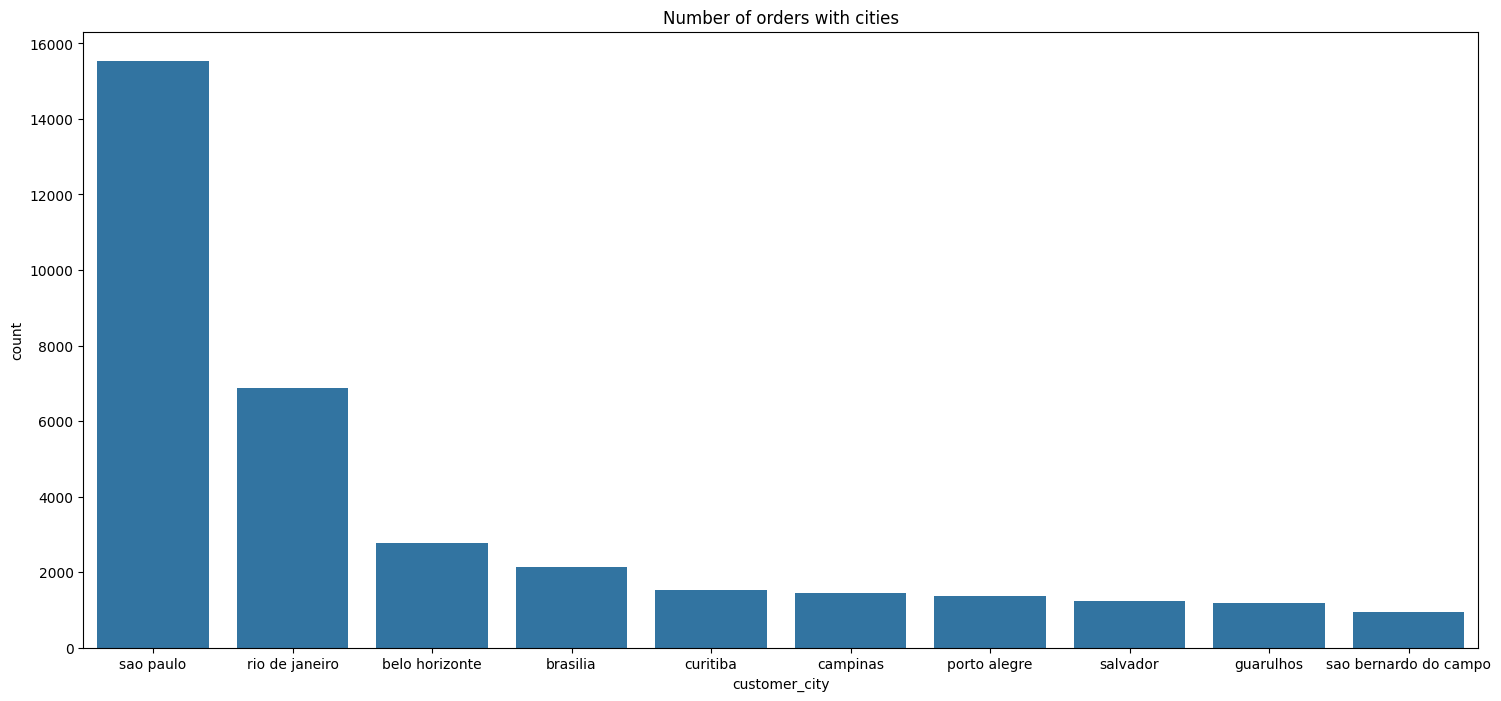

In [9]:
plt.figure(figsize=(18,8)) 
sns.barplot(df_order_analysis["customer_city"].value_counts().sort_values(ascending=False).head(10)) 
plt.title("Number of orders with cities") 
plt.show()

In [10]:
#Insight: 
#The major cities in brazil like sao paulo, rio de janerio has more number of orders in fact it leads the capitial city brasillia

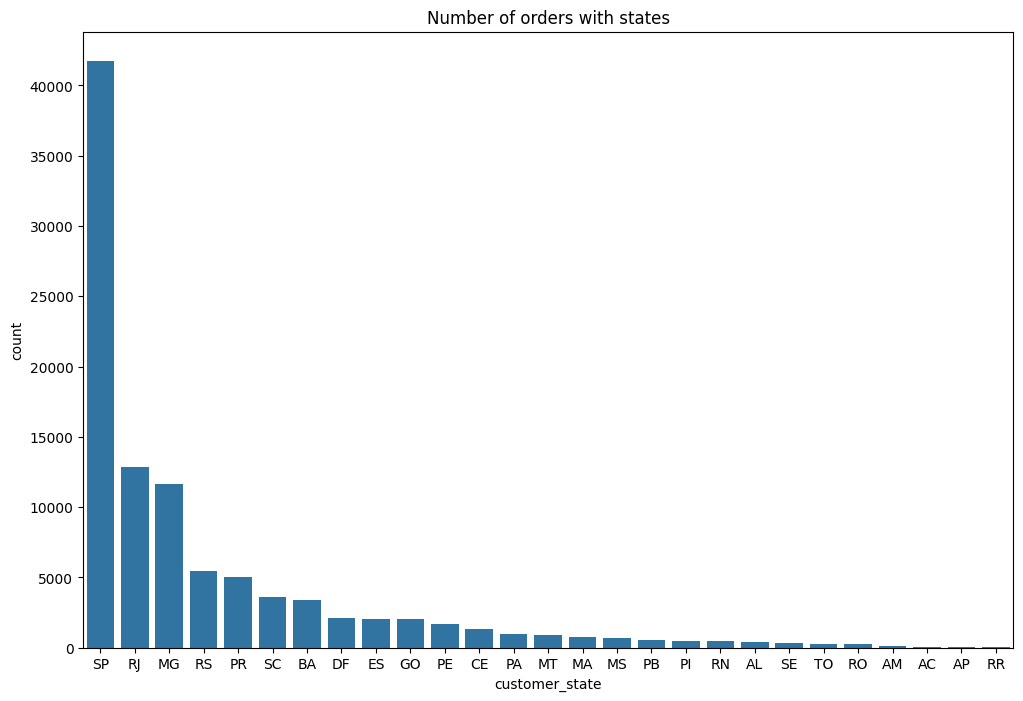

In [11]:
plt.figure(figsize=(12,8)) 
sns.barplot(df_order_analysis["customer_state"].value_counts().sort_values(ascending=False)) 
plt.title("Number of orders with states") 
plt.show()

In [12]:
#Insight: 
#States with major urban centers show higher order volumes, indicating demand concentration in metropolitan regions

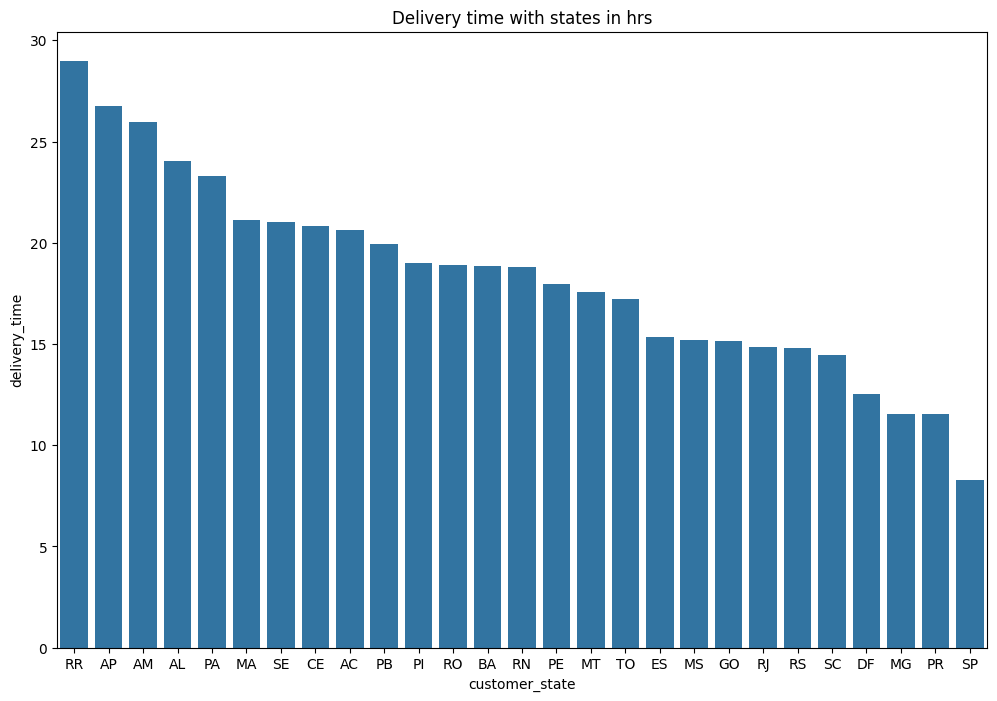

In [13]:
order=df_order_analysis.groupby("customer_state")["delivery_time"].mean().sort_values(ascending=False).index

plt.figure(figsize=(12,8)) 
sns.barplot(data=df_order_analysis, x="customer_state", y="delivery_time", estimator="mean", order=order, errorbar=None) 
plt.title("Delivery time with states in hrs") 
plt.show()

In [14]:
#Insight: 
#Sao Paulo shows the lowest delivery time, likely due to better logistics infrastructure and higher seller concentration

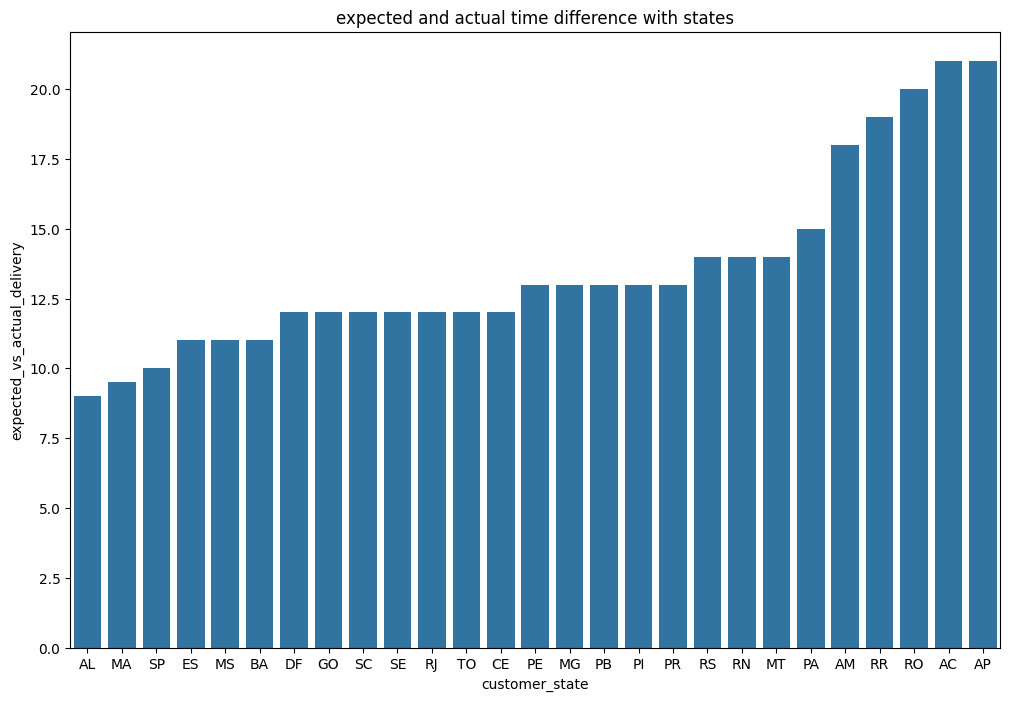

In [15]:
order=df_order_analysis.groupby("customer_state")["expected_vs_actual_delivery"].median().sort_values().index 
plt.figure(figsize=(12,8)) 
sns.barplot(data=df_order_analysis, x="customer_state", y="expected_vs_actual_delivery", estimator="median", order=order, errorbar=None) 
plt.title("expected and actual time difference with states") 
plt.show()

In [16]:
#Insight 
#The expected time is more accurate in state AL than in state AP

In [17]:
df_order_analysis["order_status"].unique()

array(['delivered', 'invoiced', 'shipped', 'processing', 'unavailable',
       'canceled', 'created', 'approved'], dtype=object)

In [18]:
df_state_total=df_order_analysis["customer_state"].value_counts().reset_index(name="count") 
df_state_total.head()

,customer_state,count
0,SP,41733
1,RJ,12850
2,MG,11632
3,RS,5463
4,PR,5045


In [19]:
df_order_status_table=df_order_analysis.groupby("customer_state")["order_status"].value_counts().reset_index(name="count") 
df_order_status_table.head()

,customer_state,order_status,count
0,AC,delivered,80
1,AC,shipped,1
2,AL,delivered,397
3,AL,shipped,9
4,AL,processing,3


In [20]:
df_order_status_percent=pd.merge(df_state_total,df_order_status_table,how="inner",on="customer_state") 
df_deliverd_percent=df_order_status_percent[df_order_status_percent["order_status"]=="delivered"].reset_index() 
df_deliverd_percent["percent_total"]=df_deliverd_percent["count_y"]/df_deliverd_percent["count_x"] 
df_deliverd_percent=df_deliverd_percent.set_index("percent_total").sort_index() 
df_deliverd_percent.head()

,index,customer_state,count_x,order_status,count_y
percent_total,,,,,
0.891304,146,RR,46,delivered,41
0.957143,124,SE,350,delivered,335
0.957303,73,CE,1335,delivered,1278
0.959786,91,MA,746,delivered,716
0.960474,134,RO,253,delivered,243


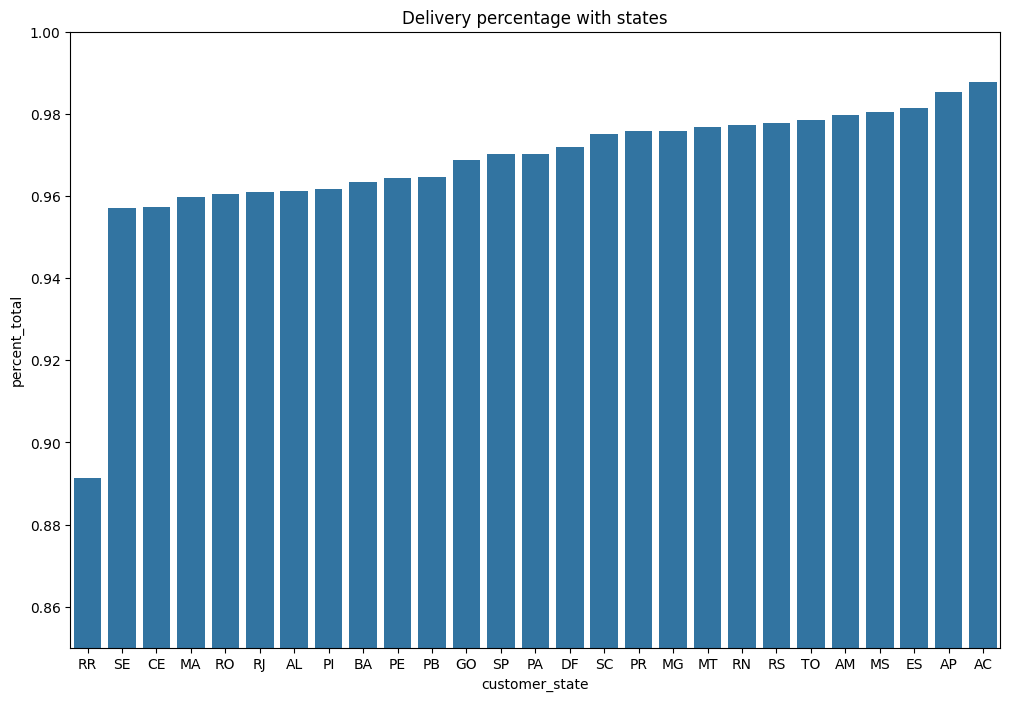

In [21]:
plt.figure(figsize=(12,8)) 
sns.barplot(data=df_deliverd_percent, x="customer_state", y="percent_total", errorbar=None) 
plt.ylim(0.85,1) 
plt.title("Delivery percentage with states") 
plt.show()

In [22]:
#Insight:
#The state RR has least delivery percentage where as the state AC has more.

In [23]:
df_cancelled_percent=df_order_status_percent[df_order_status_percent["order_status"]=="canceled"].reset_index() 
df_cancelled_percent["percent_total"]=df_cancelled_percent["count_y"]/df_cancelled_percent["count_x"] 
df_cancelled_percent=df_cancelled_percent.set_index("percent_total").sort_index() 
df_cancelled_percent.head()

,index,customer_state,count_x,order_status,count_y
percent_total,,,,,
0.002205,88,MT,907,canceled,2
0.002421,122,AL,413,canceled,1
0.002797,100,MS,715,canceled,2
0.002857,127,SE,350,canceled,1
0.003027,70,PE,1652,canceled,5


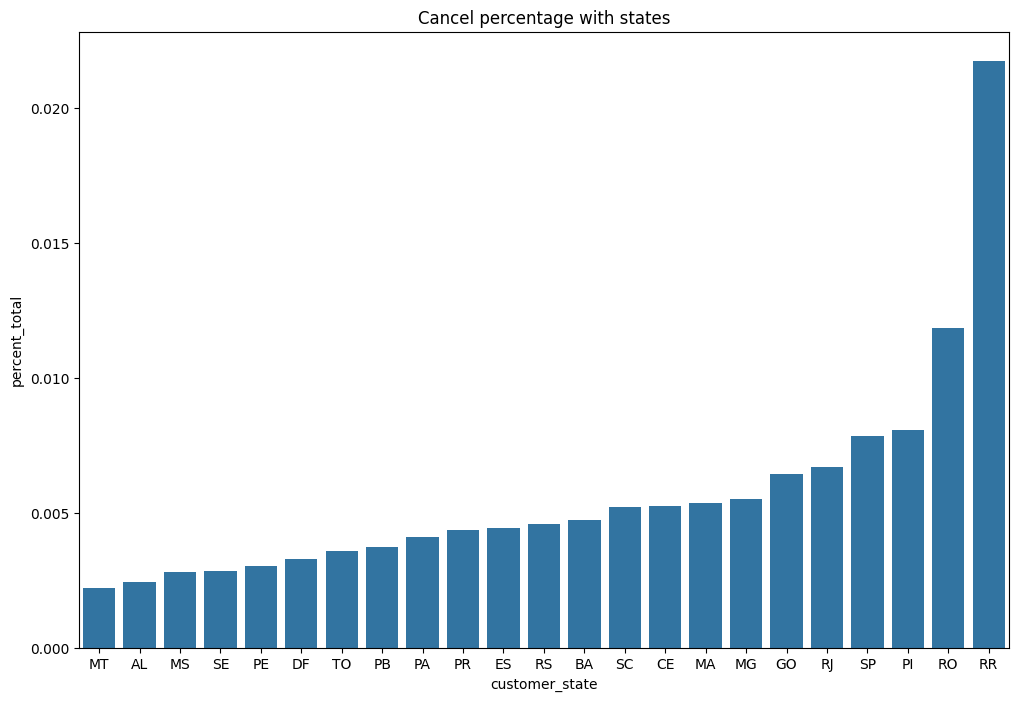

In [24]:
plt.figure(figsize=(12,8)) 
sns.barplot(data=df_cancelled_percent, x="customer_state", y="percent_total", errorbar=None) 
plt.title("Cancel percentage with states") 
plt.show()

In [25]:
#Insight: 
#The cancel percentage in state ML is least among all states with less than 0.5%!

In [26]:
df_order_analysis["purchase_month"]=df_order_analysis["order_purchase_timestamp"].dt.month 
df_order_analysis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99418 entries, 0 to 99417
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99418 non-null  object        
 1   customer_id                    99418 non-null  object        
 2   order_status                   99418 non-null  object        
 3   order_purchase_timestamp       99418 non-null  datetime64[ns]
 4   order_approved_at              99272 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97637 non-null  datetime64[ns]
 6   order_delivered_customer_date  96461 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99418 non-null  datetime64[ns]
 8   delivery_time                  96461 non-null  float64       
 9   approval_time                  99272 non-null  float64       
 10  carrier_time                   96461 non-null  float64       
 11  expected_vs_act

In [27]:
df_order_analysis["purchase_year"]=df_order_analysis["order_purchase_timestamp"].dt.year 
df_order_analysis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99418 entries, 0 to 99417
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99418 non-null  object        
 1   customer_id                    99418 non-null  object        
 2   order_status                   99418 non-null  object        
 3   order_purchase_timestamp       99418 non-null  datetime64[ns]
 4   order_approved_at              99272 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97637 non-null  datetime64[ns]
 6   order_delivered_customer_date  96461 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99418 non-null  datetime64[ns]
 8   delivery_time                  96461 non-null  float64       
 9   approval_time                  99272 non-null  float64       
 10  carrier_time                   96461 non-null  float64       
 11  expected_vs_act

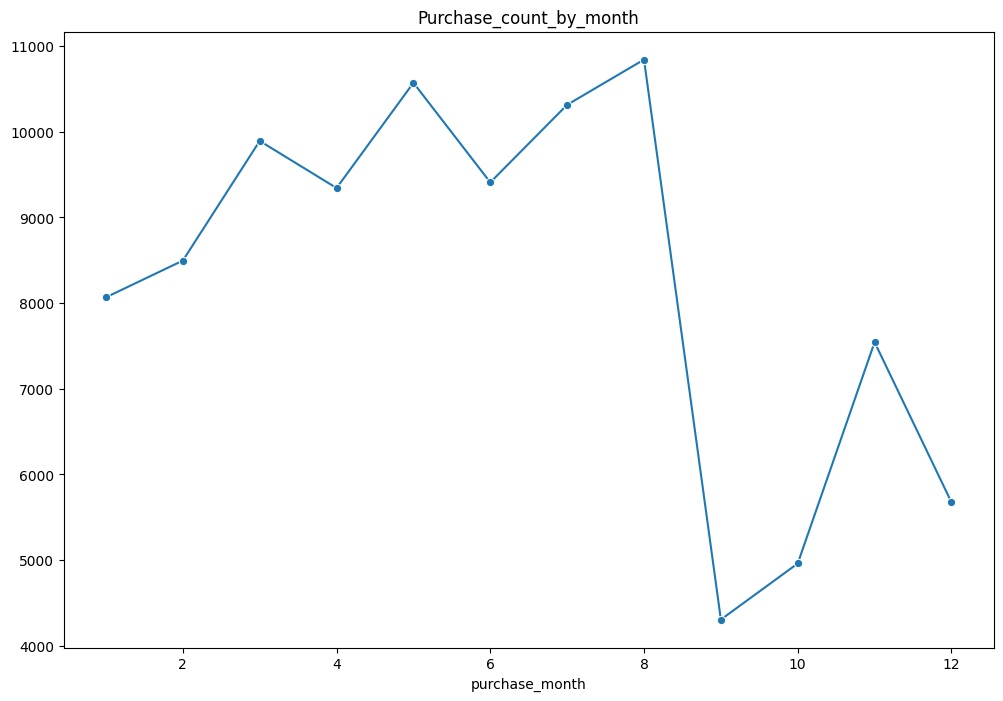

In [28]:
df_month=df_order_analysis["purchase_month"].value_counts().sort_index() 
plt.figure(figsize=(12,8)) 
sns.lineplot(x=df_month.index,y=df_month.values,marker="o") 
plt.title("Purchase_count_by_month") 
plt.show()

In [29]:
#Insight: 
#The first of the year has a lot of orders compared to second half but we can see there is a sudden drop from month 8(highes) to month 9(lowest)

In [30]:
df_order_analysis["purchase_month_year"]=df_order_analysis["order_purchase_timestamp"].dt.to_period("M") 
df_month_by_year=df_order_analysis.groupby("purchase_month_year").size()

In [31]:
df_month_by_year.index=df_month_by_year.index.to_timestamp() 
df_order_analysis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99418 entries, 0 to 99417
Data columns (total 19 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99418 non-null  object        
 1   customer_id                    99418 non-null  object        
 2   order_status                   99418 non-null  object        
 3   order_purchase_timestamp       99418 non-null  datetime64[ns]
 4   order_approved_at              99272 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97637 non-null  datetime64[ns]
 6   order_delivered_customer_date  96461 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99418 non-null  datetime64[ns]
 8   delivery_time                  96461 non-null  float64       
 9   approval_time                  99272 non-null  float64       
 10  carrier_time                   96461 non-null  float64       
 11  expected_vs_act

In [32]:
print("Min",df_order_analysis["order_purchase_timestamp"].min()) 
print("Max",df_order_analysis["order_purchase_timestamp"].max())

Min 2016-09-04 21:15:19
Max 2018-10-17 17:30:18


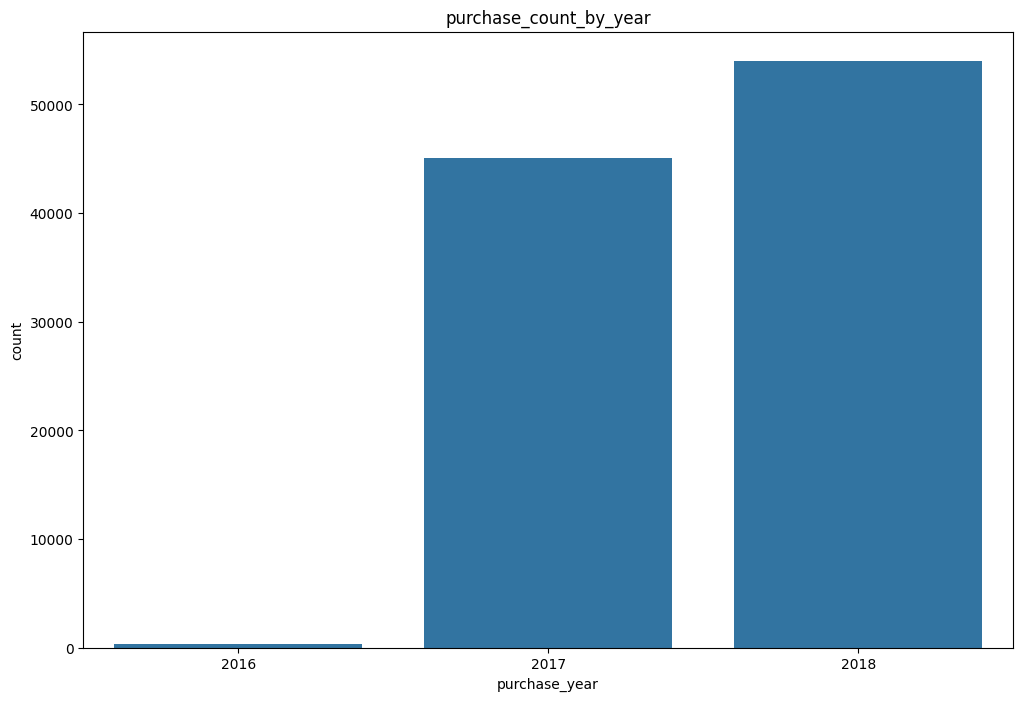

In [33]:
plt.figure(figsize=(12,8)) 
sns.barplot(df_order_analysis["purchase_year"].value_counts()) 
plt.title("purchase_count_by_year") 
plt.show()

In [34]:
#Insight: 
#Let us leave year 2016 as only few month datas are available but we can see there is a huge increase in online orders from year 17 to 18

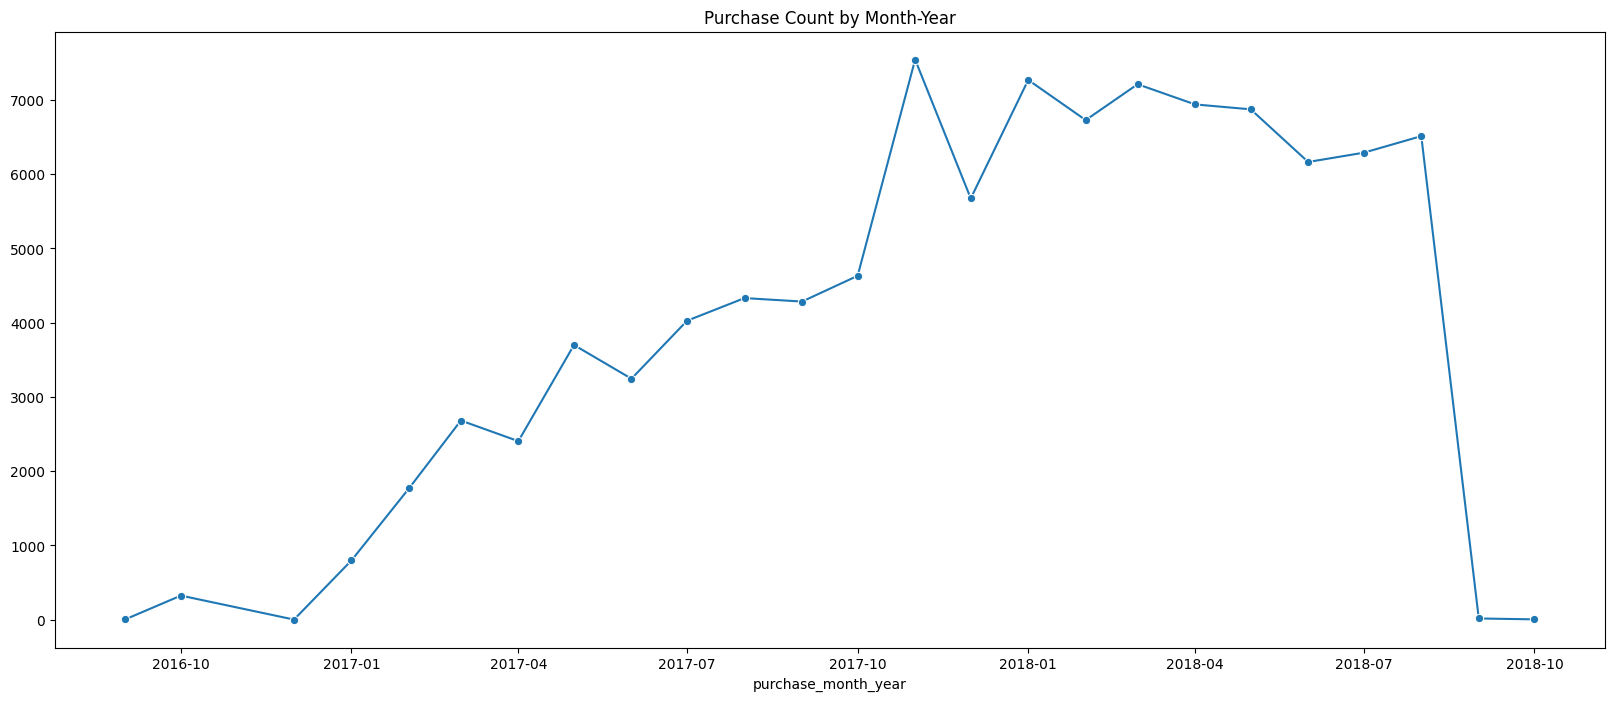

In [35]:
plt.figure(figsize=(20,8)) 
sns.lineplot(x=df_month_by_year.index,y=df_month_by_year.values,marker="o") 
plt.title("Purchase Count by Month-Year") 
plt.show()

In [36]:
#Insight
#We can see a gradual increase in number of online orders as year passes a=the drop at last is due to lack of data

In [37]:
df_order_analysis["purchase_time"]=df_order_analysis["order_purchase_timestamp"].dt.hour 
df_order_analysis.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,approval_time,carrier_time,expected_vs_actual_delivery,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,purchase_month,purchase_year,purchase_month_year,purchase_time
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,0.0,6.0,7.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,10,2017,2017-10,10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,1.0,12.0,5.0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,7,2018,2018-07,20
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,0.0,9.0,17.0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,8,2018,2018-08,8
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,0.0,9.0,12.0,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,11,2017,2017-11,19
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,0.0,1.0,9.0,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,2,2018,2018-02,21


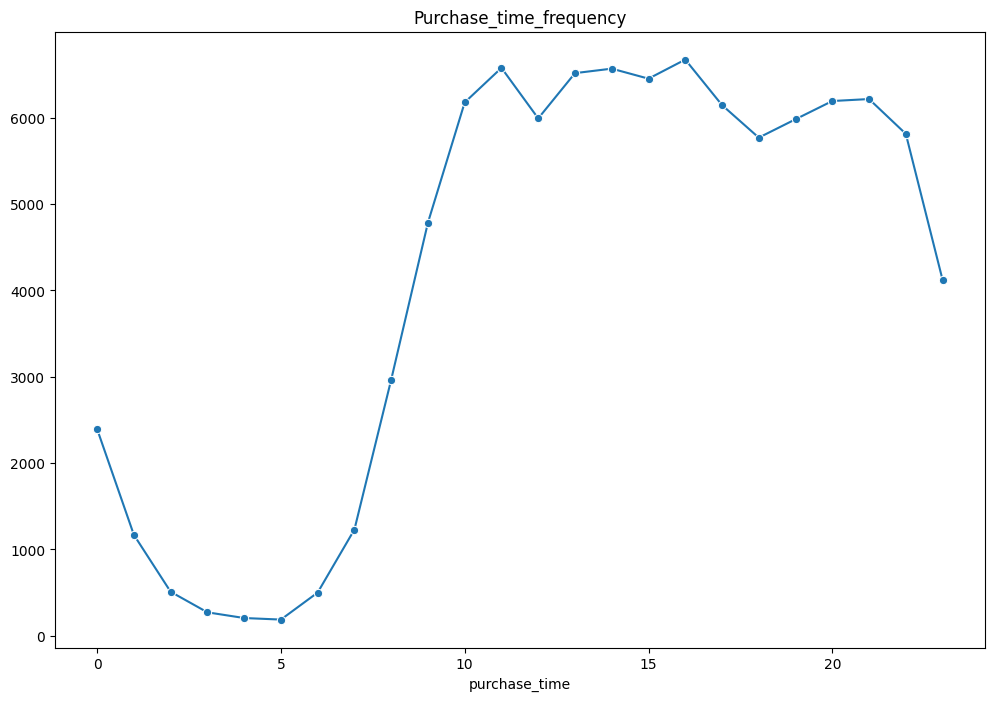

In [38]:
df_time=df_order_analysis["purchase_time"].value_counts().sort_index() 
plt.figure(figsize=(12,8)) 
sns.lineplot(x=df_time.index,y=df_time.values,marker="o") 
plt.title("Purchase_time_frequency") 
plt.show()

In [39]:
#Insight 
#People place their order mostly after morning 10 AM and moves gradually till 8-9 PM

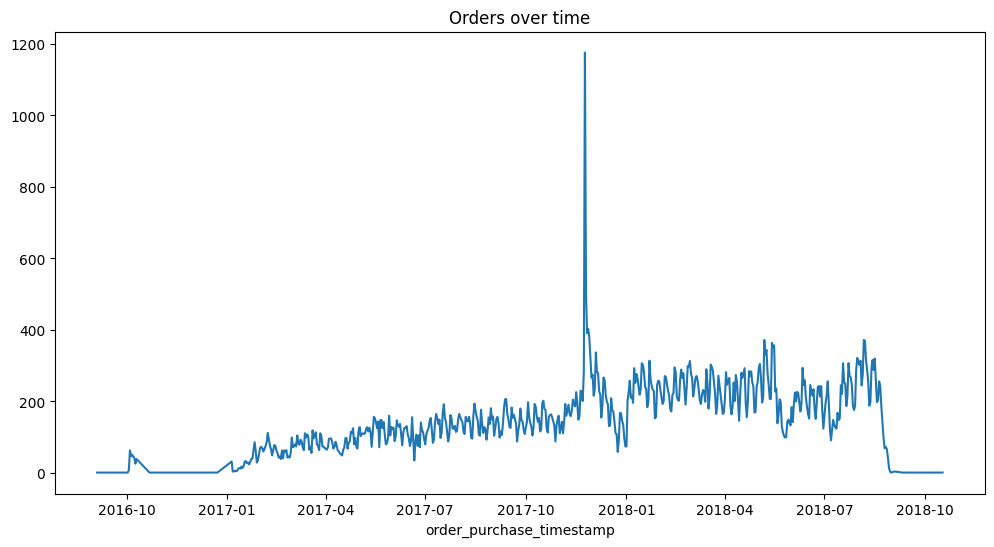

In [40]:
df_daily=df_order_analysis.groupby(df_order_analysis["order_purchase_timestamp"].dt.date).size() 
plt.figure(figsize=(12,6)) 
sns.lineplot(x=df_daily.index,y=df_daily.values) 
plt.title("Orders over time") 
plt.show()

In [41]:
#Insight: 
#Here we can cleary the see the black friday effect as other days has average of 300-400 we see a sudden increase in one day on 2017-11-24 with 1176 orders

### Section 2: Orders + Customers + Items Analysis

In [42]:
df_order_items=pd.read_csv("preprocessed_olist_order_items_dataset.csv") 
df_order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,sum_original_and_freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,259.83
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,218.04


In [43]:
df_order_items["shipping_limit_date"]=pd.to_datetime(df_order_items["shipping_limit_date"])
df_order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 8 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   order_id                        112650 non-null  object        
 1   order_item_id                   112650 non-null  int64         
 2   product_id                      112650 non-null  object        
 3   seller_id                       112650 non-null  object        
 4   shipping_limit_date             112650 non-null  datetime64[ns]
 5   price                           112650 non-null  float64       
 6   freight_value                   112650 non-null  float64       
 7   sum_original_and_freight_value  112650 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(3)
memory usage: 6.9+ MB


In [44]:
df_base.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,approval_time,carrier_time,expected_vs_actual_delivery,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,0.0,6.0,7.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,1.0,12.0,5.0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,0.0,9.0,17.0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,0.0,9.0,12.0,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,0.0,1.0,9.0,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [45]:
df_order_items_analysis=pd.merge(df_base,df_order_items,on="order_id",how="inner") 
df_order_items_analysis.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,approval_time,...,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,sum_original_and_freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,0.0,...,3149,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,1.0,...,47813,barreiras,BA,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,0.0,...,75265,vianopolis,GO,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,0.0,...,59296,sao goncalo do amarante,RN,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,0.0,...,9195,santo andre,SP,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,28.62


In [46]:
df_order_items_analysis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112626 entries, 0 to 112625
Data columns (total 23 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   order_id                        112626 non-null  object        
 1   customer_id                     112626 non-null  object        
 2   order_status                    112626 non-null  object        
 3   order_purchase_timestamp        112626 non-null  datetime64[ns]
 4   order_approved_at               112626 non-null  datetime64[ns]
 5   order_delivered_carrier_date    111434 non-null  datetime64[ns]
 6   order_delivered_customer_date   110180 non-null  datetime64[ns]
 7   order_estimated_delivery_date   112626 non-null  datetime64[ns]
 8   delivery_time                   110180 non-null  float64       
 9   approval_time                   112626 non-null  float64       
 10  carrier_time                    110180 non-null  float64

In [47]:
df_order_items_analysis["shipping_date_limit_check"]=(df_order_items_analysis["shipping_limit_date"]-df_order_items_analysis["order_delivered_carrier_date"]).dt.days
df_order_items_analysis["shipping_date_limit_check"] =df_order_items_analysis["shipping_date_limit_check"].apply(
    lambda x: "Delivered within time" if x > 0 
    else "Delivered on time" if x == 0 
    else "Delayed delivery"
)

In [48]:
df_order_items_analysis["order_id"].value_counts().sort_values(ascending=False)

order_id
8272b63d03f5f79c56e9e4120aec44ef    21
1b15974a0141d54e36626dca3fdc731a    20
ab14fdcfbe524636d65ee38360e22ce8    20
9ef13efd6949e4573a18964dd1bbe7f5    15
428a2f660dc84138d969ccd69a0ab6d5    15
                                    ..
f9e3402be5a5ea63344347582ca9f45f     1
6f46d42016226f77893ed3978d6903d0     1
dfc6eb45a2753ed9e6c6ef4987b44503     1
38e9133ce29f6bbe35aed9c3863dce01     1
f6f9344efc918f1e00ab84c014aa21d7     1
Name: count, Length: 98643, dtype: int64

In [49]:
df_order_items_analysis["order_id"].value_counts().sort_values(ascending=False)

order_id
8272b63d03f5f79c56e9e4120aec44ef    21
1b15974a0141d54e36626dca3fdc731a    20
ab14fdcfbe524636d65ee38360e22ce8    20
9ef13efd6949e4573a18964dd1bbe7f5    15
428a2f660dc84138d969ccd69a0ab6d5    15
                                    ..
f9e3402be5a5ea63344347582ca9f45f     1
6f46d42016226f77893ed3978d6903d0     1
dfc6eb45a2753ed9e6c6ef4987b44503     1
38e9133ce29f6bbe35aed9c3863dce01     1
f6f9344efc918f1e00ab84c014aa21d7     1
Name: count, Length: 98643, dtype: int64

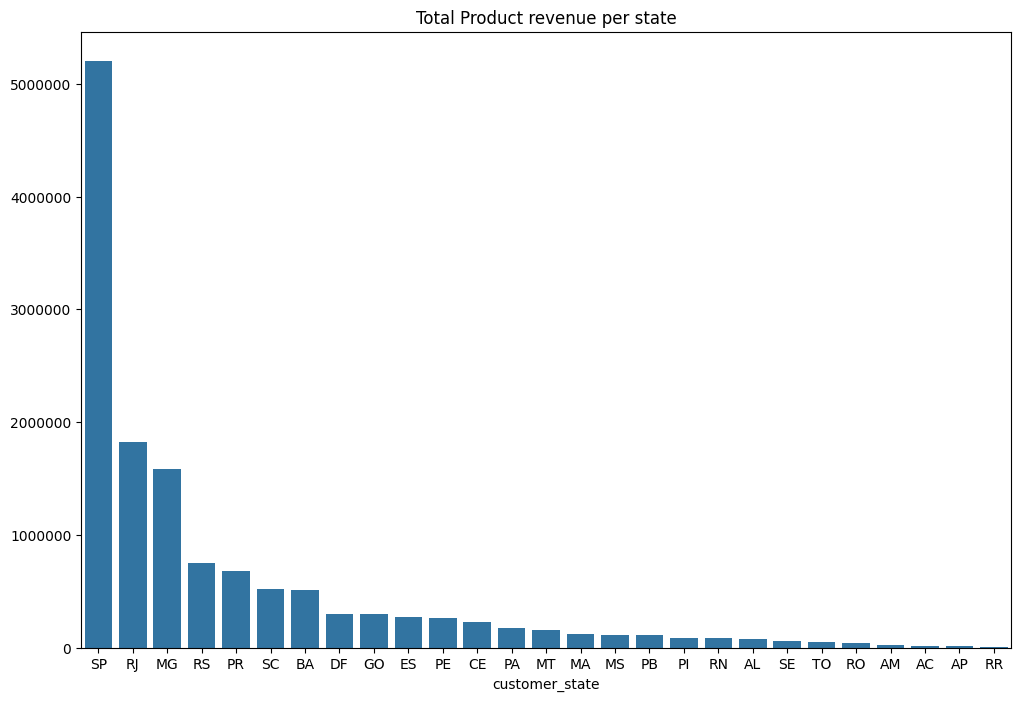

In [50]:
total_revenue_per_state=df_order_items_analysis.groupby("customer_state")["price"].sum().sort_values(ascending=False) 
plt.figure(figsize=(12,8)) 
sns.barplot(x=total_revenue_per_state.index,y=total_revenue_per_state.values) 
plt.ticklabel_format(style='plain', axis='y') 
plt.title("Total Product revenue per state") 
plt.show()

In [51]:
#Insight: 
#Since the number of orders in sao paulo is higher (as we seen earlier) the total product revenue is being high

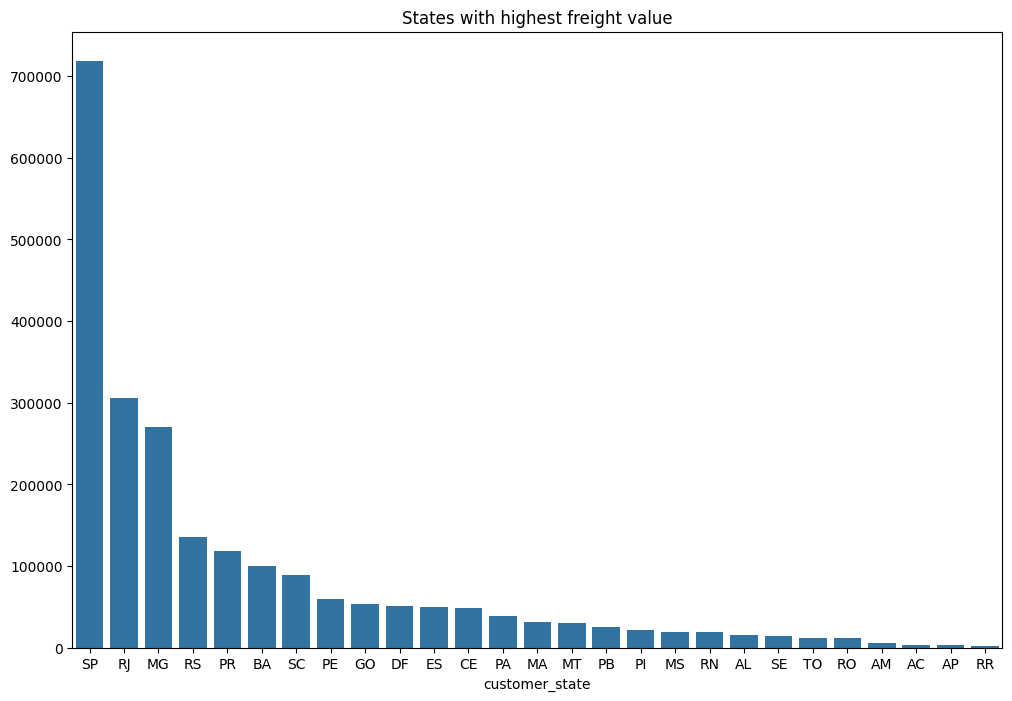

In [52]:
total_freight_per_state=df_order_items_analysis.groupby("customer_state")["freight_value"].sum().sort_values(ascending=False) 
plt.figure(figsize=(12,8)) 
sns.barplot(x=total_freight_per_state.index,y=total_freight_per_state.values) 
plt.title("States with highest freight value") 
plt.show()

In [53]:
#Insight: 
#Same like product revenue orders influence the freight value too

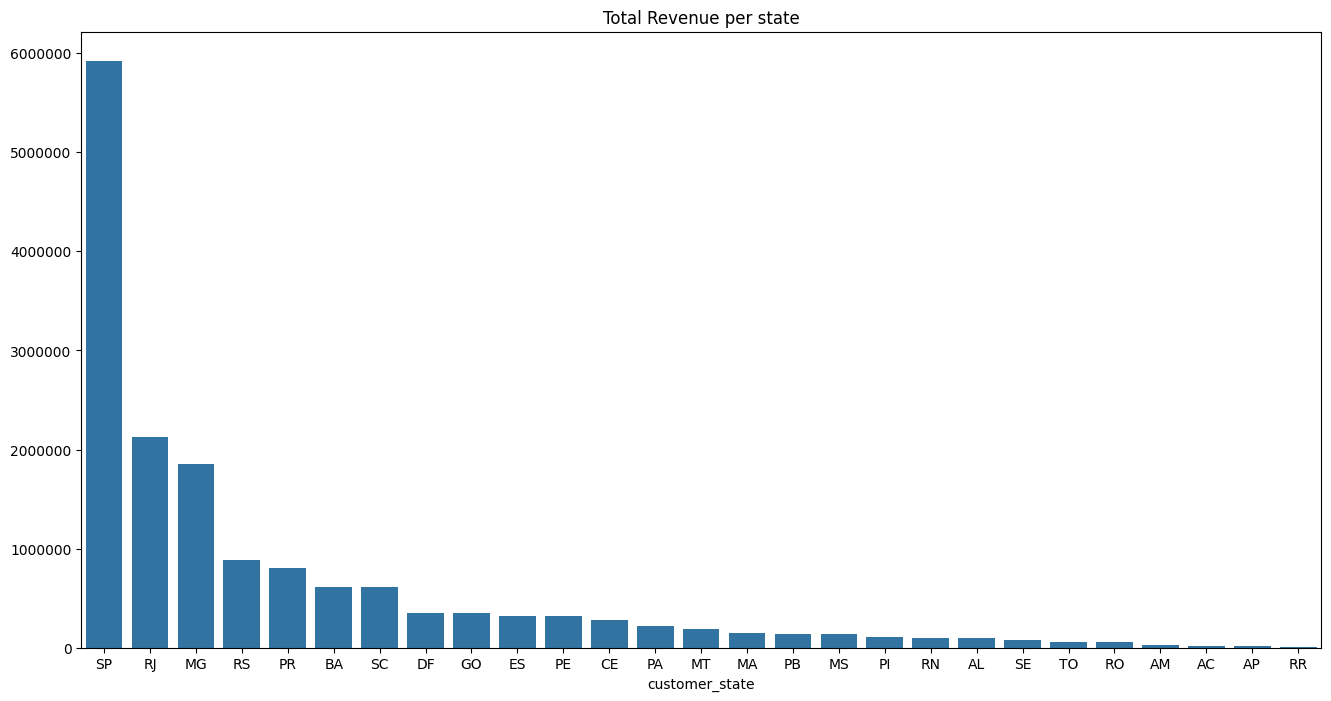

In [54]:
total_sum_revenue_per_state=df_order_items_analysis.groupby("customer_state")["sum_original_and_freight_value"].sum().sort_values(ascending=False)

plt.figure(figsize=(16,8)) 
sns.barplot(x=total_sum_revenue_per_state.index,y=total_sum_revenue_per_state.values) 
plt.ticklabel_format(style='plain', axis='y') 
plt.title("Total Revenue per state") 
plt.show()

In [55]:
#Insight: 
#Sao Paulo dominates total revenue, contributing a significant share, indicating strong demand concentration in this region.

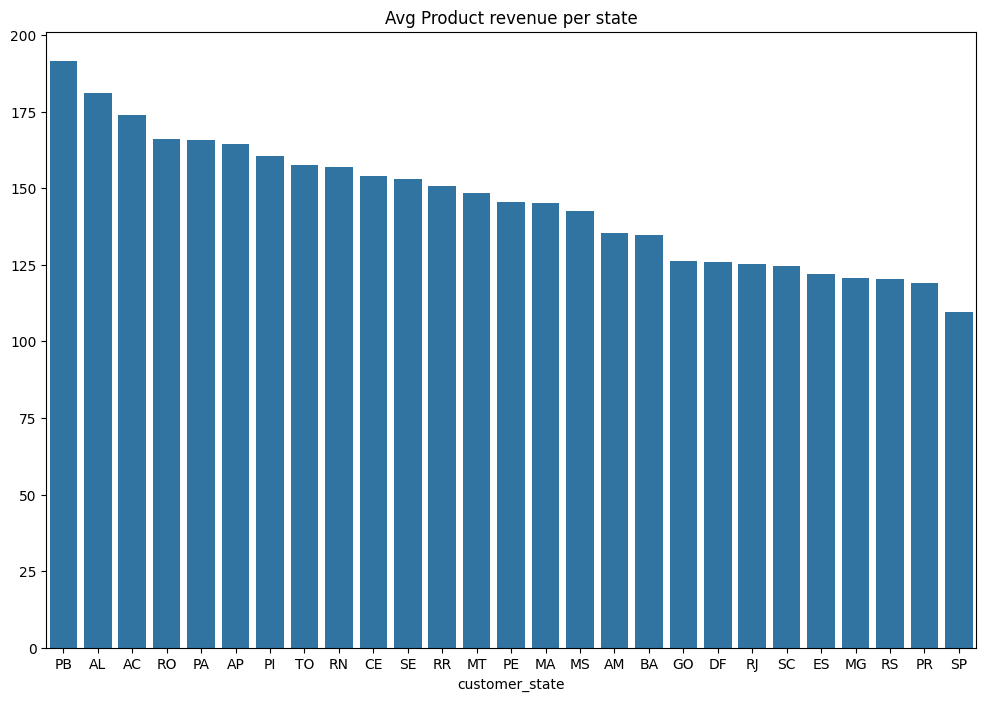

In [56]:
avg_revenue_per_state=df_order_items_analysis.groupby("customer_state")["price"].mean().sort_values(ascending=False) 
plt.figure(figsize=(12,8)) 
sns.barplot(x=avg_revenue_per_state.index,y=avg_revenue_per_state.values) 
plt.ticklabel_format(style='plain',axis='y') 
plt.title("Avg Product revenue per state") 
plt.show()

In [57]:
#Insight: 
#Avg product revenue in sao paulo is being the least indicating the the people buying comparatively cheaper products

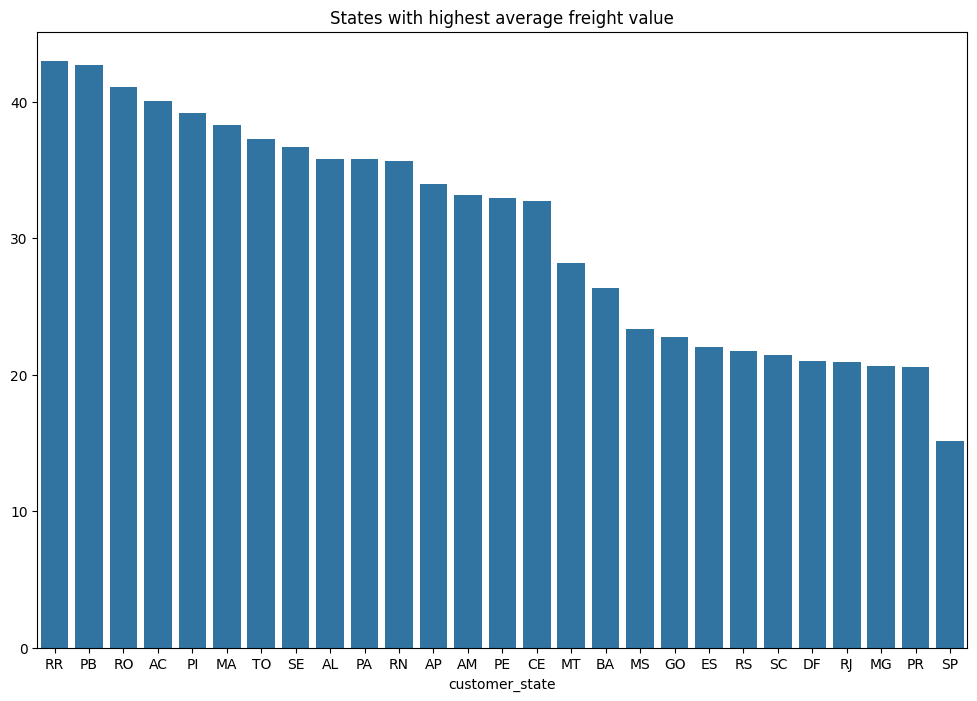

In [58]:
avg_freight_per_state=df_order_items_analysis.groupby("customer_state")["freight_value"].mean().sort_values(ascending=False) 
plt.figure(figsize=(12,8)) 
sns.barplot(x=avg_freight_per_state.index,y=avg_freight_per_state.values) 
plt.title("States with highest average freight value") 
plt.show()

In [59]:
#Insight: 
#The freight value in sao paulo is being the least indicating the transportation facility and carrier services or even short distance

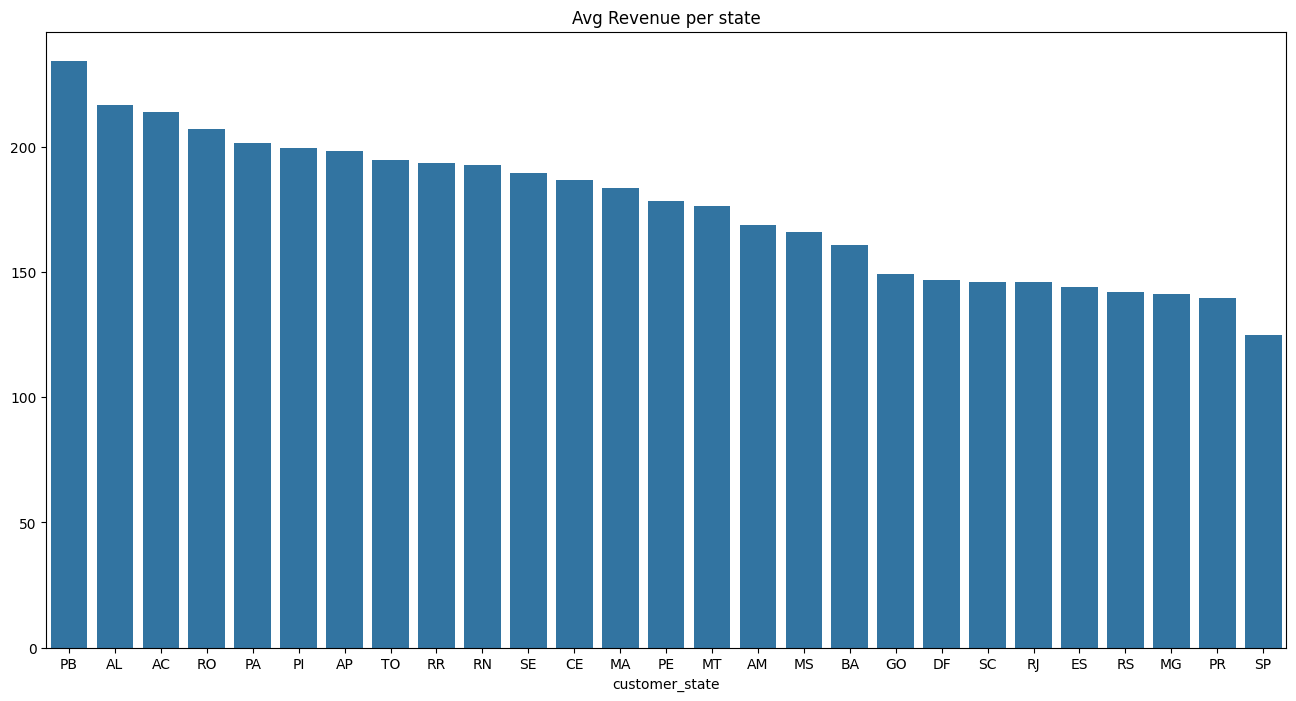

In [60]:
avg_sum_revenue_per_state=df_order_items_analysis.groupby("customer_state")["sum_original_and_freight_value"].mean().sort_values(ascending=False) 
plt.figure(figsize=(16,8)) 
sns.barplot(x=avg_sum_revenue_per_state.index,y=avg_sum_revenue_per_state.values) 
plt.ticklabel_format(style='plain', axis='y') 
plt.title("Avg Revenue per state") 
plt.show()

In [61]:
#Insight:
#Even though sao paulo topped the highest total revene in average revenue it is being least indicating availability of cheap products.

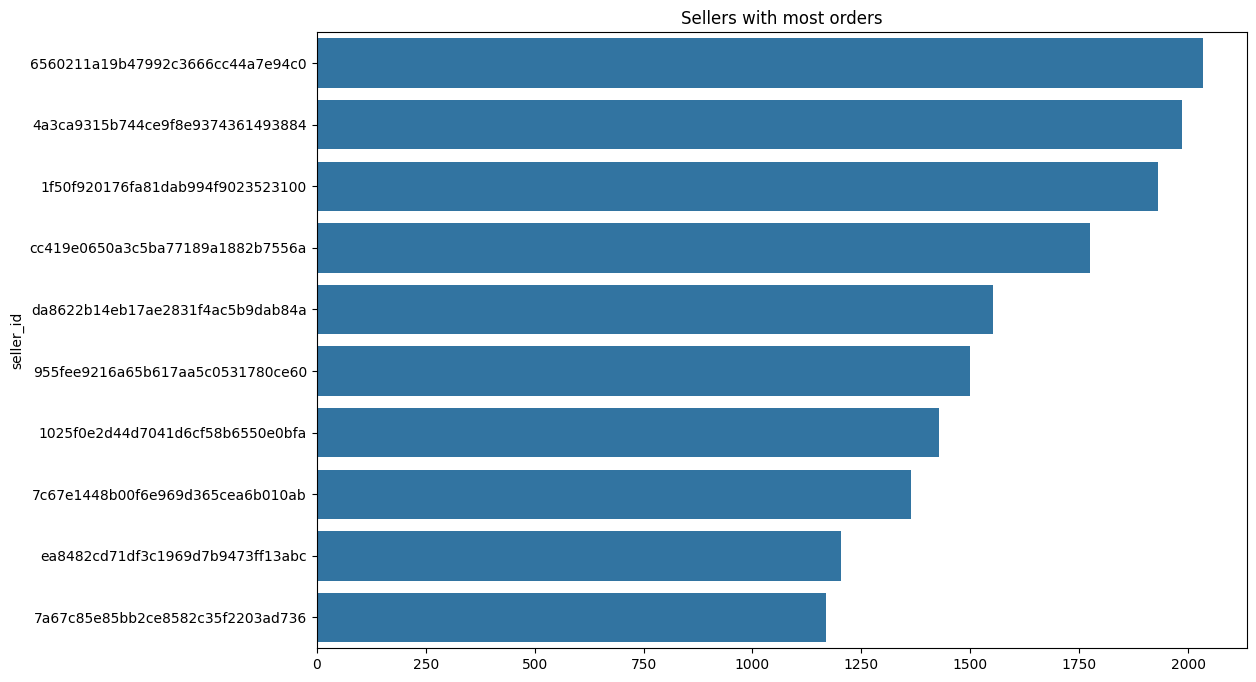

In [62]:
df_sellers_orders=df_order_items_analysis["seller_id"].value_counts().head(10) 
plt.figure(figsize=(12,8)) 
sns.barplot(x=df_sellers_orders.values,y=df_sellers_orders.index) 
plt.title("Sellers with most orders") 
plt.show()

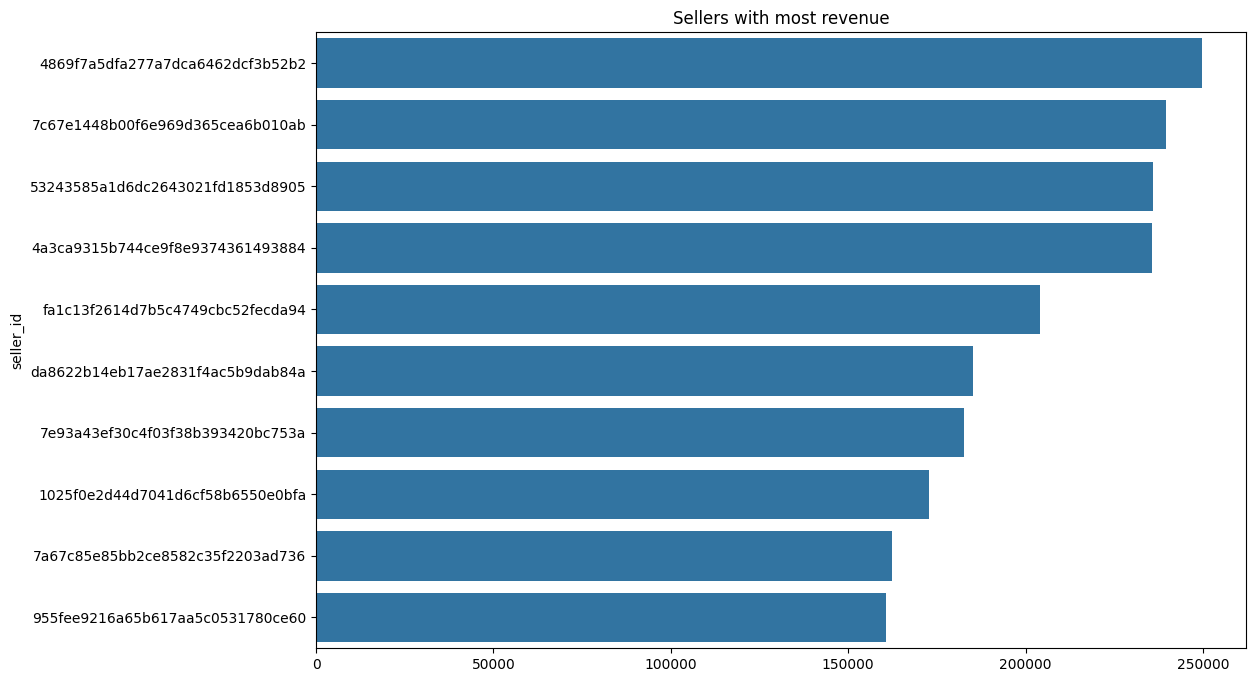

In [63]:
df_sellers_revenue=df_order_items_analysis.groupby("seller_id")["sum_original_and_freight_value"].sum().sort_values(ascending=False).head(10) 
plt.figure(figsize=(12,8)) 
sns.barplot(x=df_sellers_revenue.values,y=df_sellers_revenue.index) 
plt.title("Sellers with most revenue") 
plt.show()

In [64]:
#Insight: 
#From both the graph we can see the seller with most order did not make top 10 in total revenue indicating he sold a product with chepaer price and also we can see some sellers in both plot.

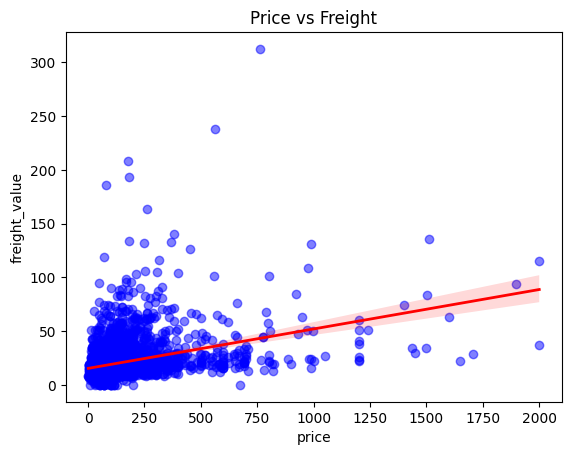

In [ ]:
sns.regplot(data=df_order_items_analysis.sample(5000),x="price",y="freight_value",scatter_kws={"color": "blue", "alpha": 0.5},line_kws={"color": "red", "linewidth": 2} ) 
plt.title("Product Price vs Freight") 
plt.show()

In [66]:
#Insight: 
#We can slightly see a increase in freight value with increase in product price.

<Axes: ylabel='count'>

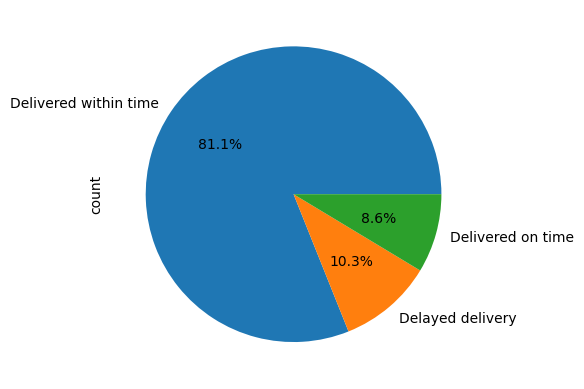

In [67]:
df_order_items_analysis["shipping_date_limit_check"].value_counts().plot.pie(autopct="%1.1f%%")

In [68]:
#Insight:
#Sellers are more cautious to deliver their product to the carrier within the deadline

### Section 3: Orders + Customers + Items + Products

In [69]:
df_base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99418 entries, 0 to 99417
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99418 non-null  object        
 1   customer_id                    99418 non-null  object        
 2   order_status                   99418 non-null  object        
 3   order_purchase_timestamp       99418 non-null  datetime64[ns]
 4   order_approved_at              99272 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97637 non-null  datetime64[ns]
 6   order_delivered_customer_date  96461 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99418 non-null  datetime64[ns]
 8   delivery_time                  96461 non-null  float64       
 9   approval_time                  99272 non-null  float64       
 10  carrier_time                   96461 non-null  float64       
 11  expected_vs_act

In [70]:
df_products=pd.read_csv("preprocessed_olist_products_dataset.csv") 
df_products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,volume_of_product_cm3
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,2240.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,10800.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,2430.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,2704.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,4420.0


In [71]:
df_items_products=df_base.merge(df_order_items,on="order_id",how="inner").merge(df_products,on="product_id",how="inner") 
df_items_products.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'delivery_time', 'approval_time', 'carrier_time',
       'expected_vs_actual_delivery', 'customer_unique_id',
       'customer_zip_code_prefix', 'customer_city', 'customer_state',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'sum_original_and_freight_value',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'volume_of_product_cm3'],
      dtype='object')

In [72]:
df_items_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112626 entries, 0 to 112625
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   order_id                        112626 non-null  object        
 1   customer_id                     112626 non-null  object        
 2   order_status                    112626 non-null  object        
 3   order_purchase_timestamp        112626 non-null  datetime64[ns]
 4   order_approved_at               112626 non-null  datetime64[ns]
 5   order_delivered_carrier_date    111434 non-null  datetime64[ns]
 6   order_delivered_customer_date   110180 non-null  datetime64[ns]
 7   order_estimated_delivery_date   112626 non-null  datetime64[ns]
 8   delivery_time                   110180 non-null  float64       
 9   approval_time                   112626 non-null  float64       
 10  carrier_time                    110180 non-null  float64

In [73]:
df_translation=pd.read_csv("preprocessed_product_category_name_translation.csv") 
df_translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [74]:
df_items_products_english=pd.merge(df_items_products,df_translation,on="product_category_name",how="inner") 
df_items_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112626 entries, 0 to 112625
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   order_id                        112626 non-null  object        
 1   customer_id                     112626 non-null  object        
 2   order_status                    112626 non-null  object        
 3   order_purchase_timestamp        112626 non-null  datetime64[ns]
 4   order_approved_at               112626 non-null  datetime64[ns]
 5   order_delivered_carrier_date    111434 non-null  datetime64[ns]
 6   order_delivered_customer_date   110180 non-null  datetime64[ns]
 7   order_estimated_delivery_date   112626 non-null  datetime64[ns]
 8   delivery_time                   110180 non-null  float64       
 9   approval_time                   112626 non-null  float64       
 10  carrier_time                    110180 non-null  float64

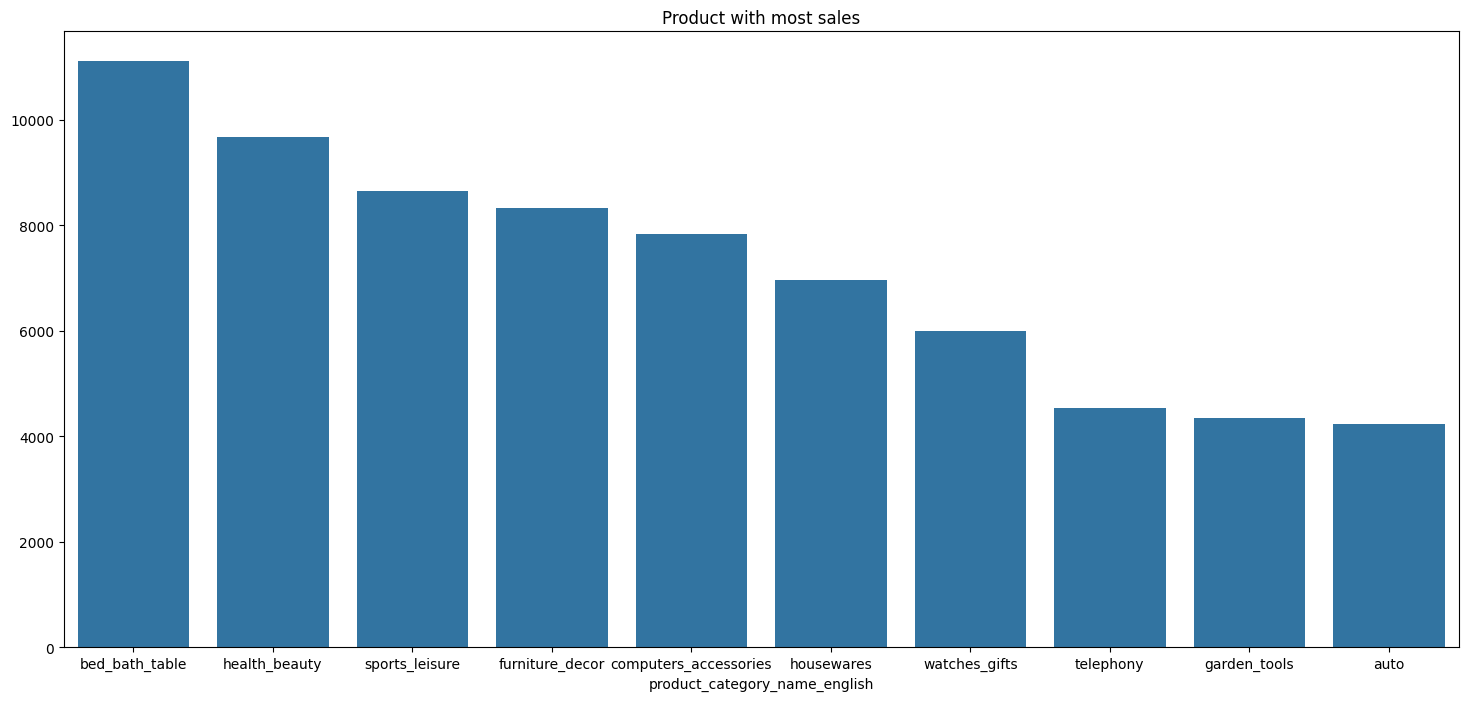

In [75]:
product_category_count=df_items_products_english["product_category_name_english"].value_counts().sort_values(ascending=False).head(10) 
plt.figure(figsize=(18,8)) 
sns.barplot(x=product_category_count.index,y=product_category_count.values) 
plt.title("Product with most sales") 
plt.show()

In [76]:
#Insight:
#The non-technical items are comparitively bought more then the technical items where watch alone made to top 10

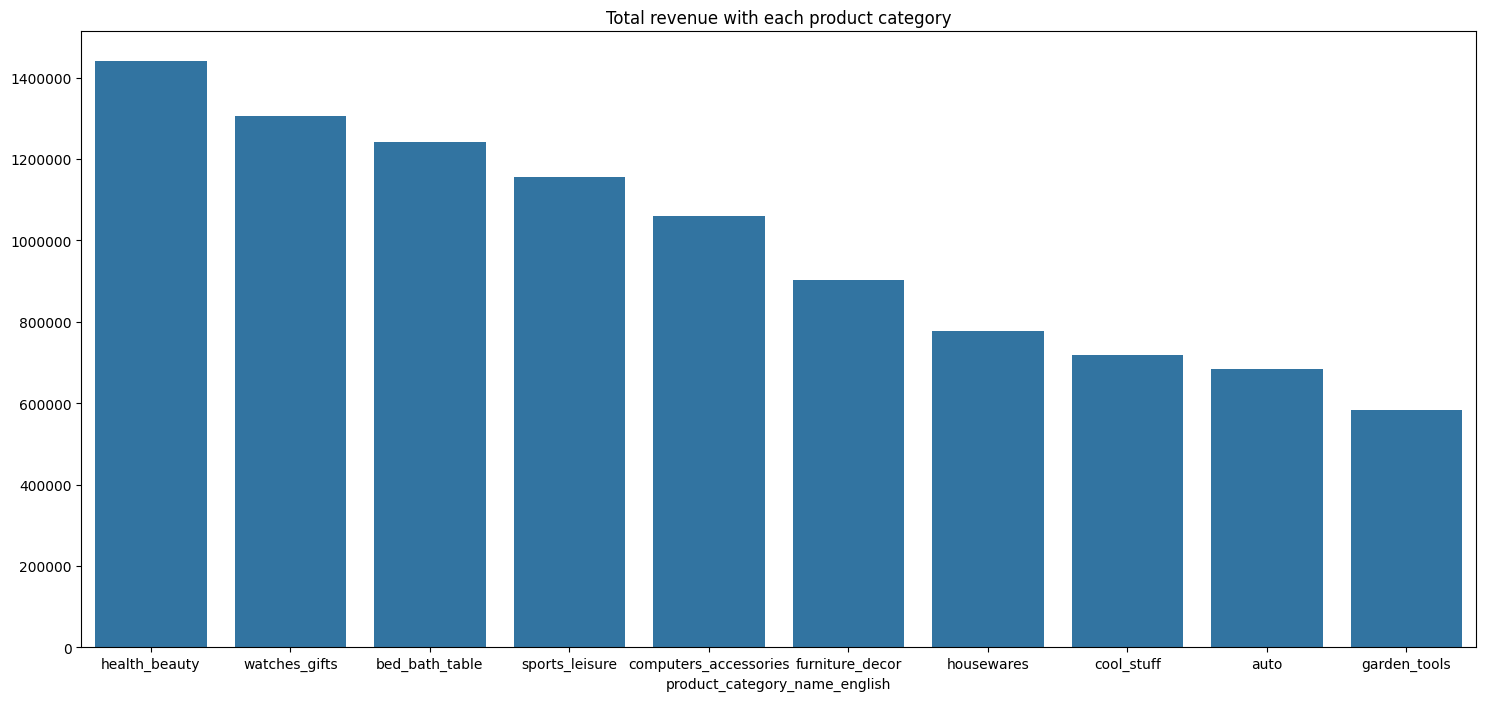

In [77]:
product_revenue=df_items_products_english.groupby("product_category_name_english")["sum_original_and_freight_value"].sum().sort_values(ascending=False).head(10) 
plt.figure(figsize=(18,8)) 
sns.barplot(x=product_revenue.index,y=product_revenue.values) 
plt.ticklabel_format(style='plain',axis='y') 
plt.title("Total revenue with each product category") 
plt.show()

In [78]:
#Insight:
#Most of the product whose sales being high repeats in the most revenue

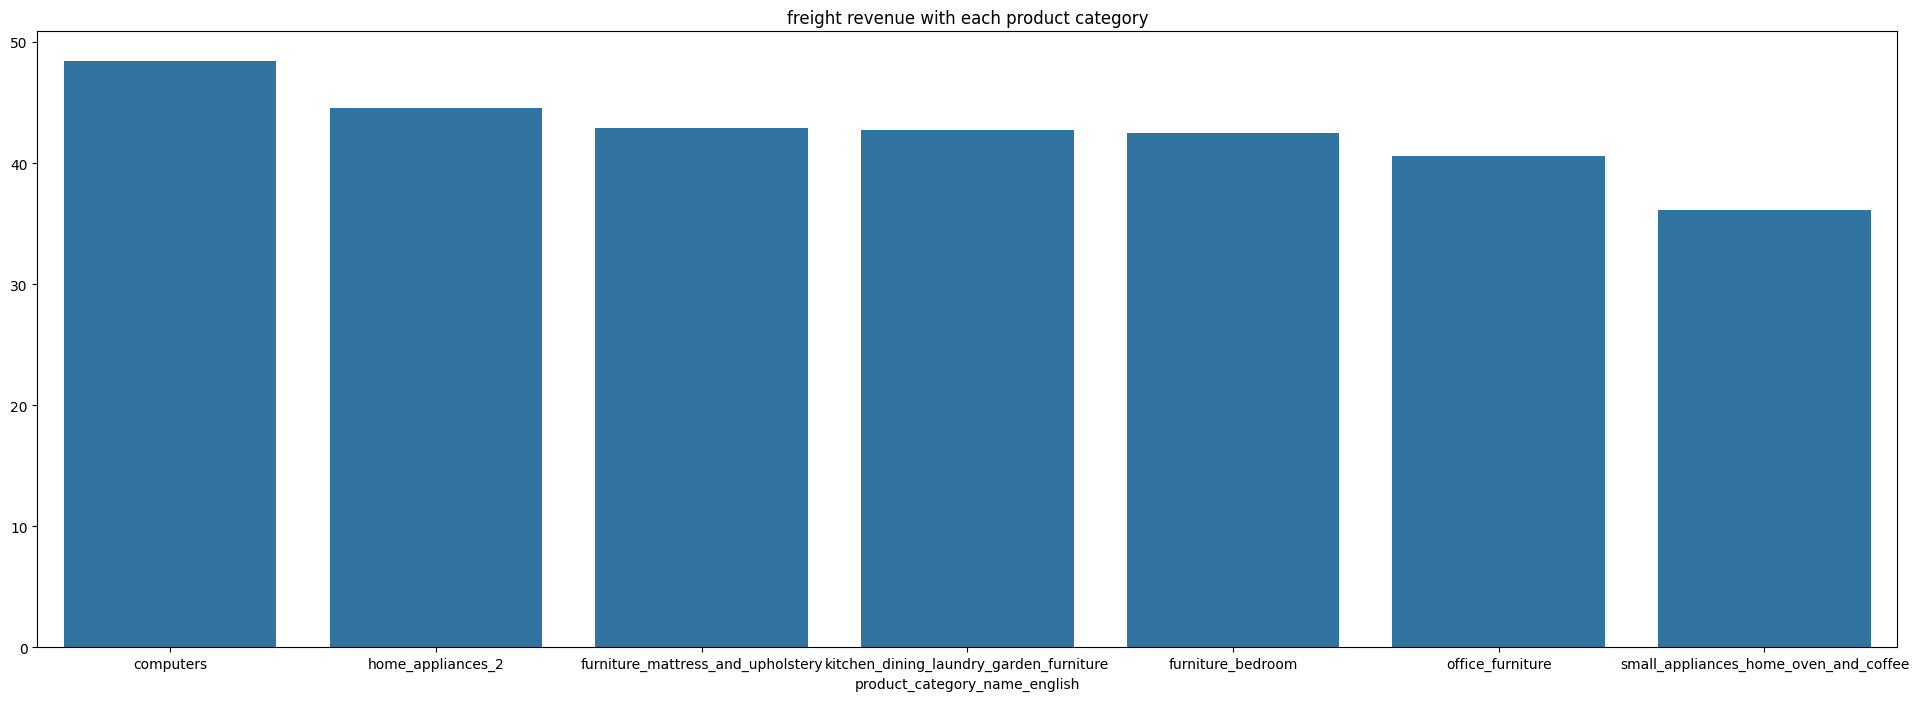

In [ ]:
product_revenue_freight=df_items_products_english.groupby("product_category_name_english")["freight_value"].mean().sort_values(ascending=False).head(7) 
plt.figure(figsize=(24,8)) 
sns.barplot(x=product_revenue_freight.index,y=product_revenue_freight.values) 
plt.ticklabel_format(style='plain',axis='y') 
plt.title("highest freight revenue with each product category") 
plt.show()

In [80]:
#Insight:
#heavy products like computers, furnitures tops the list of the freight value

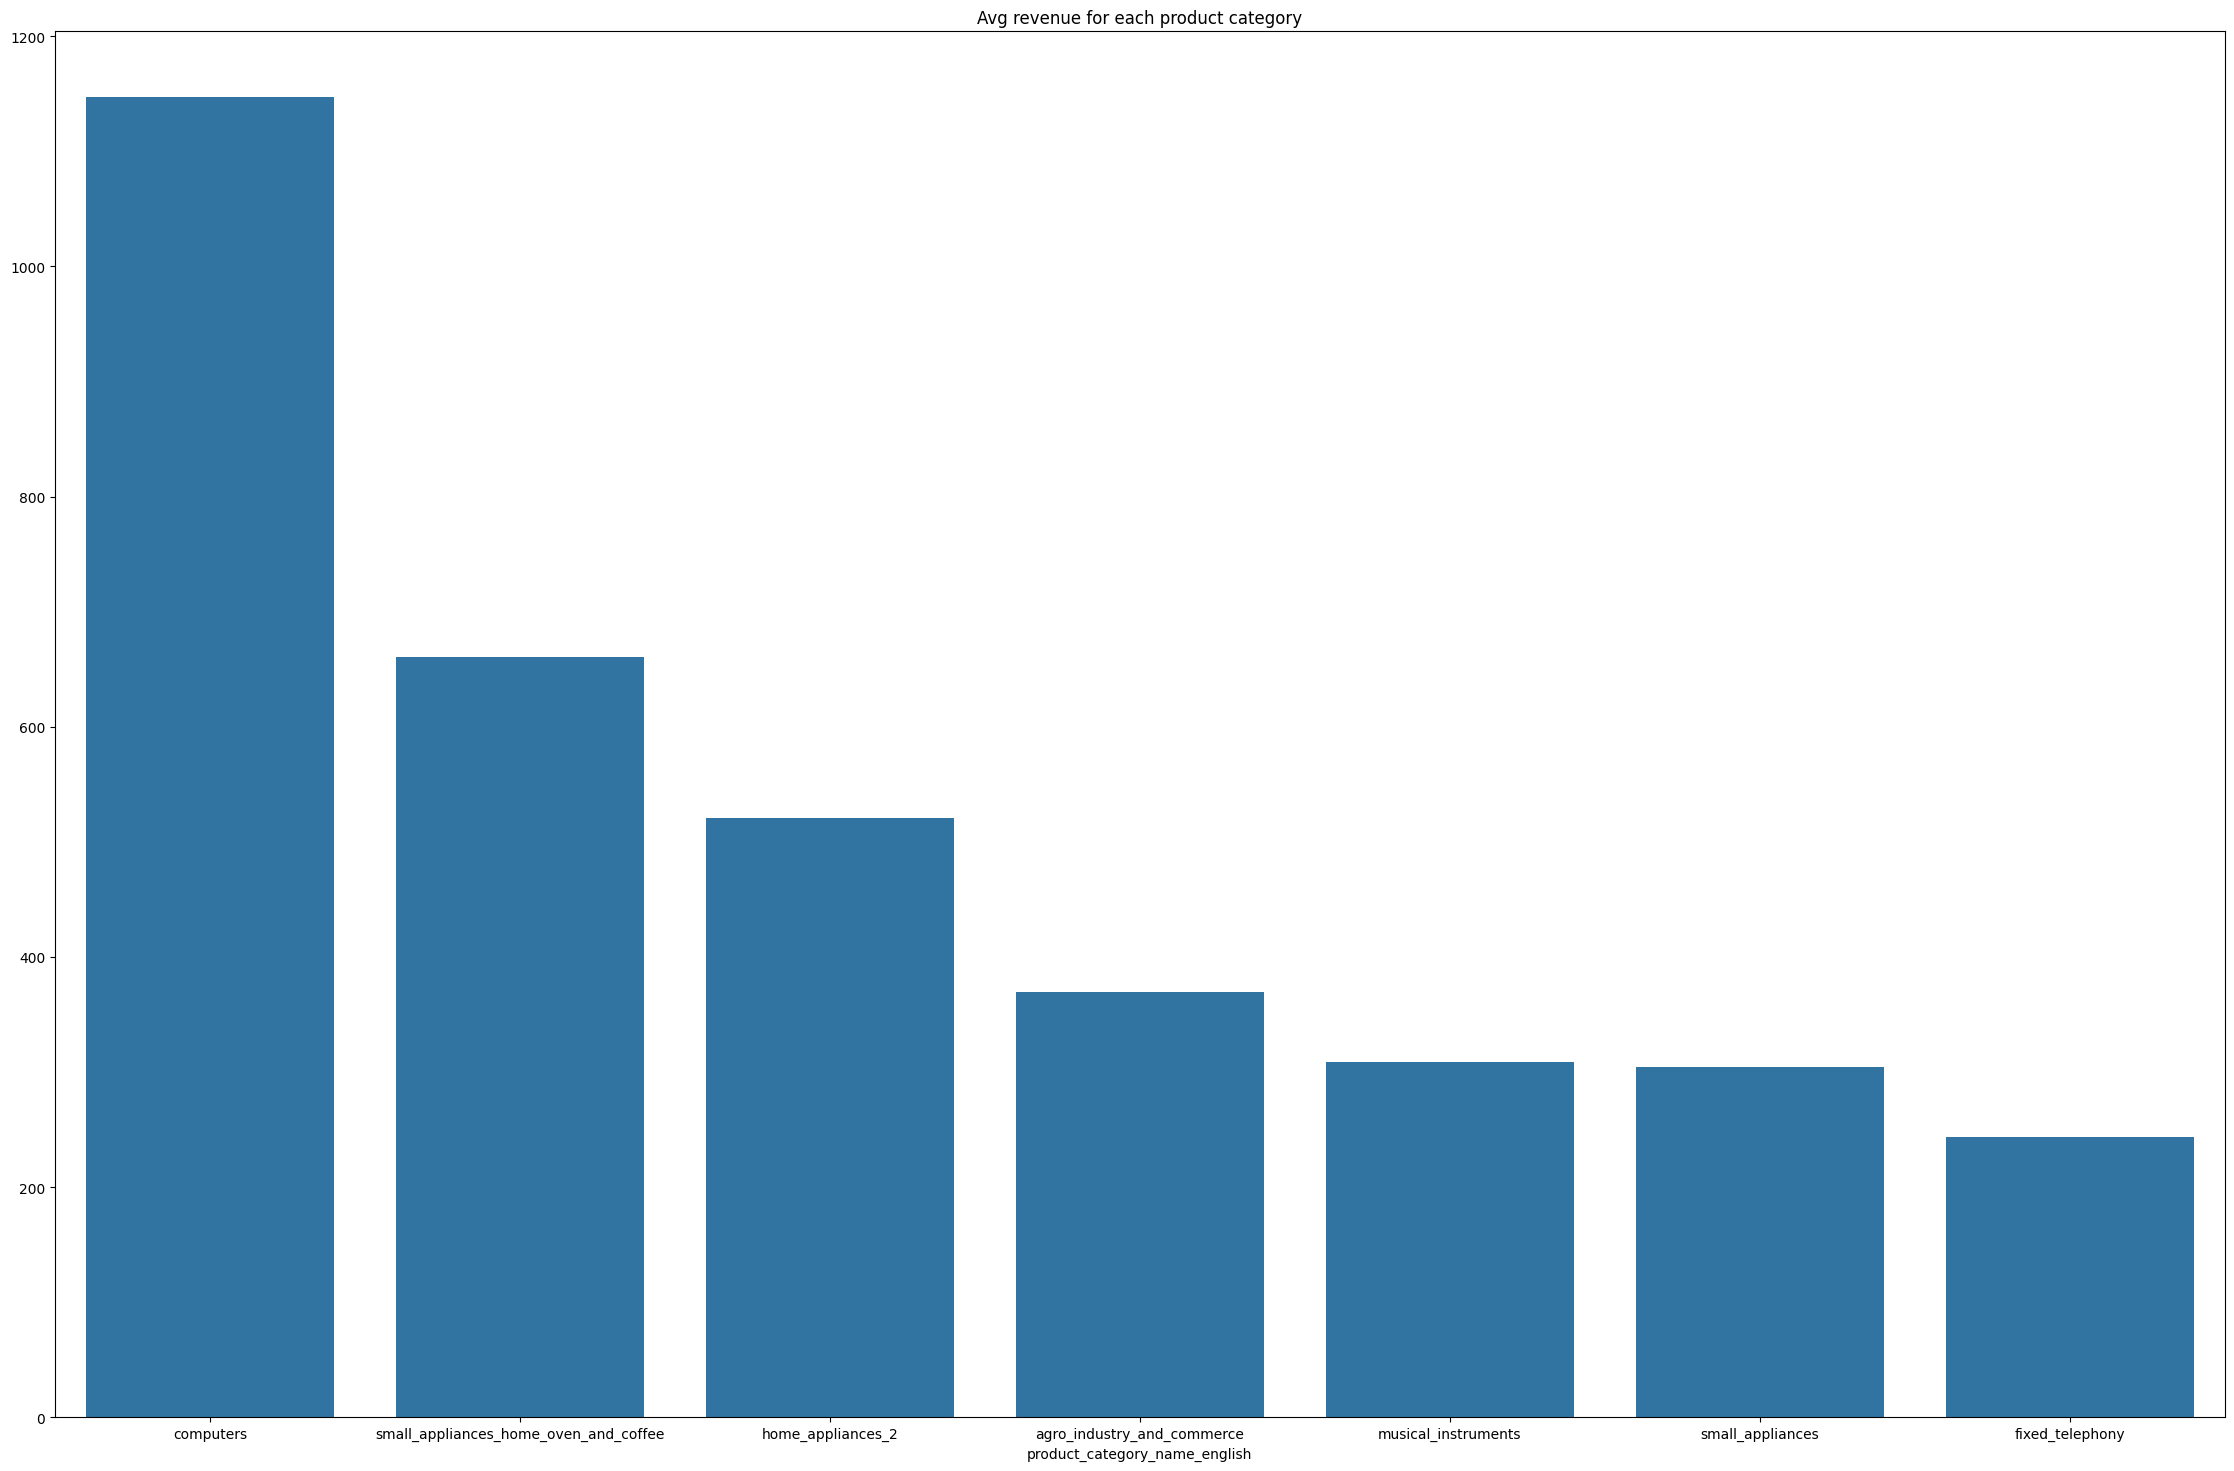

In [81]:
product_avg_revenue=df_items_products_english.groupby("product_category_name_english")["sum_original_and_freight_value"].mean().sort_values(ascending=False).head(7) 
plt.figure(figsize=(28,18)) 
sns.barplot(x=product_avg_revenue.index,y=product_avg_revenue.values) 
plt.ticklabel_format(style='plain',axis='y') 
plt.title("Avg revenue for each product category") 
plt.show()

In [82]:
#Insight:
#The average revenue is being high in heavy products like computers, musical instruments, furnitures etc

Text(0.5, 1.0, 'Description Length vs Orders')

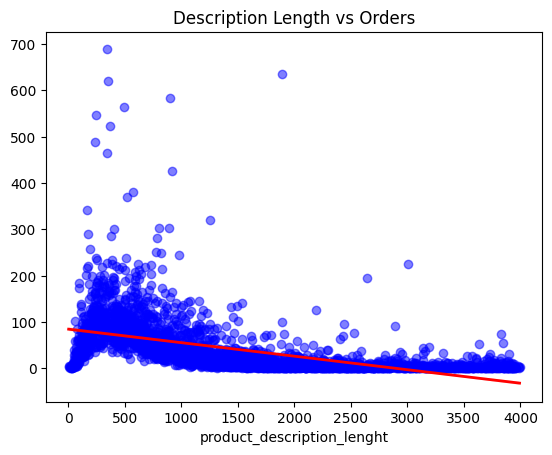

In [83]:
df_desc=df_items_products_english.groupby("product_description_lenght")["order_id"].count()

sns.regplot(x=df_desc.index,y=df_desc.values,scatter_kws={"color": "blue", "alpha": 0.5},line_kws={"color": "red", "linewidth": 2} )
plt.title("Description Length vs Orders")

In [84]:
#Insight:
#As we can see the description with length between 0-1500 is ideal as whose sales were being high and after that by increasing the length the orders decreases

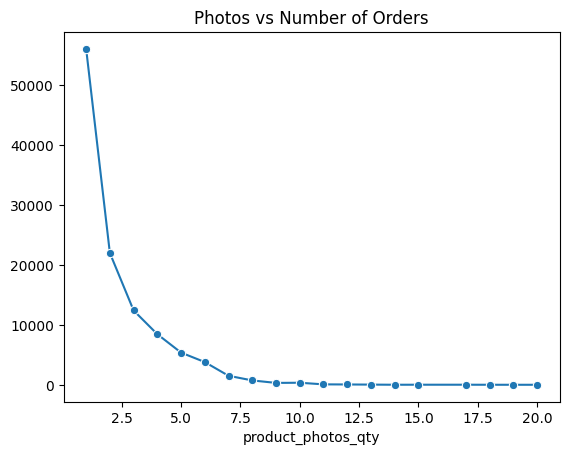

In [85]:
photo_vs_orders =df_items_products_english.groupby("product_photos_qty")["order_id"].count()

sns.lineplot(x=photo_vs_orders.index,y=photo_vs_orders.values,marker="o")
plt.title("Photos vs Number of Orders")
plt.show()

In [86]:
#Insight:
#This is actually surprising that products with less photos has better sales than one with more photos

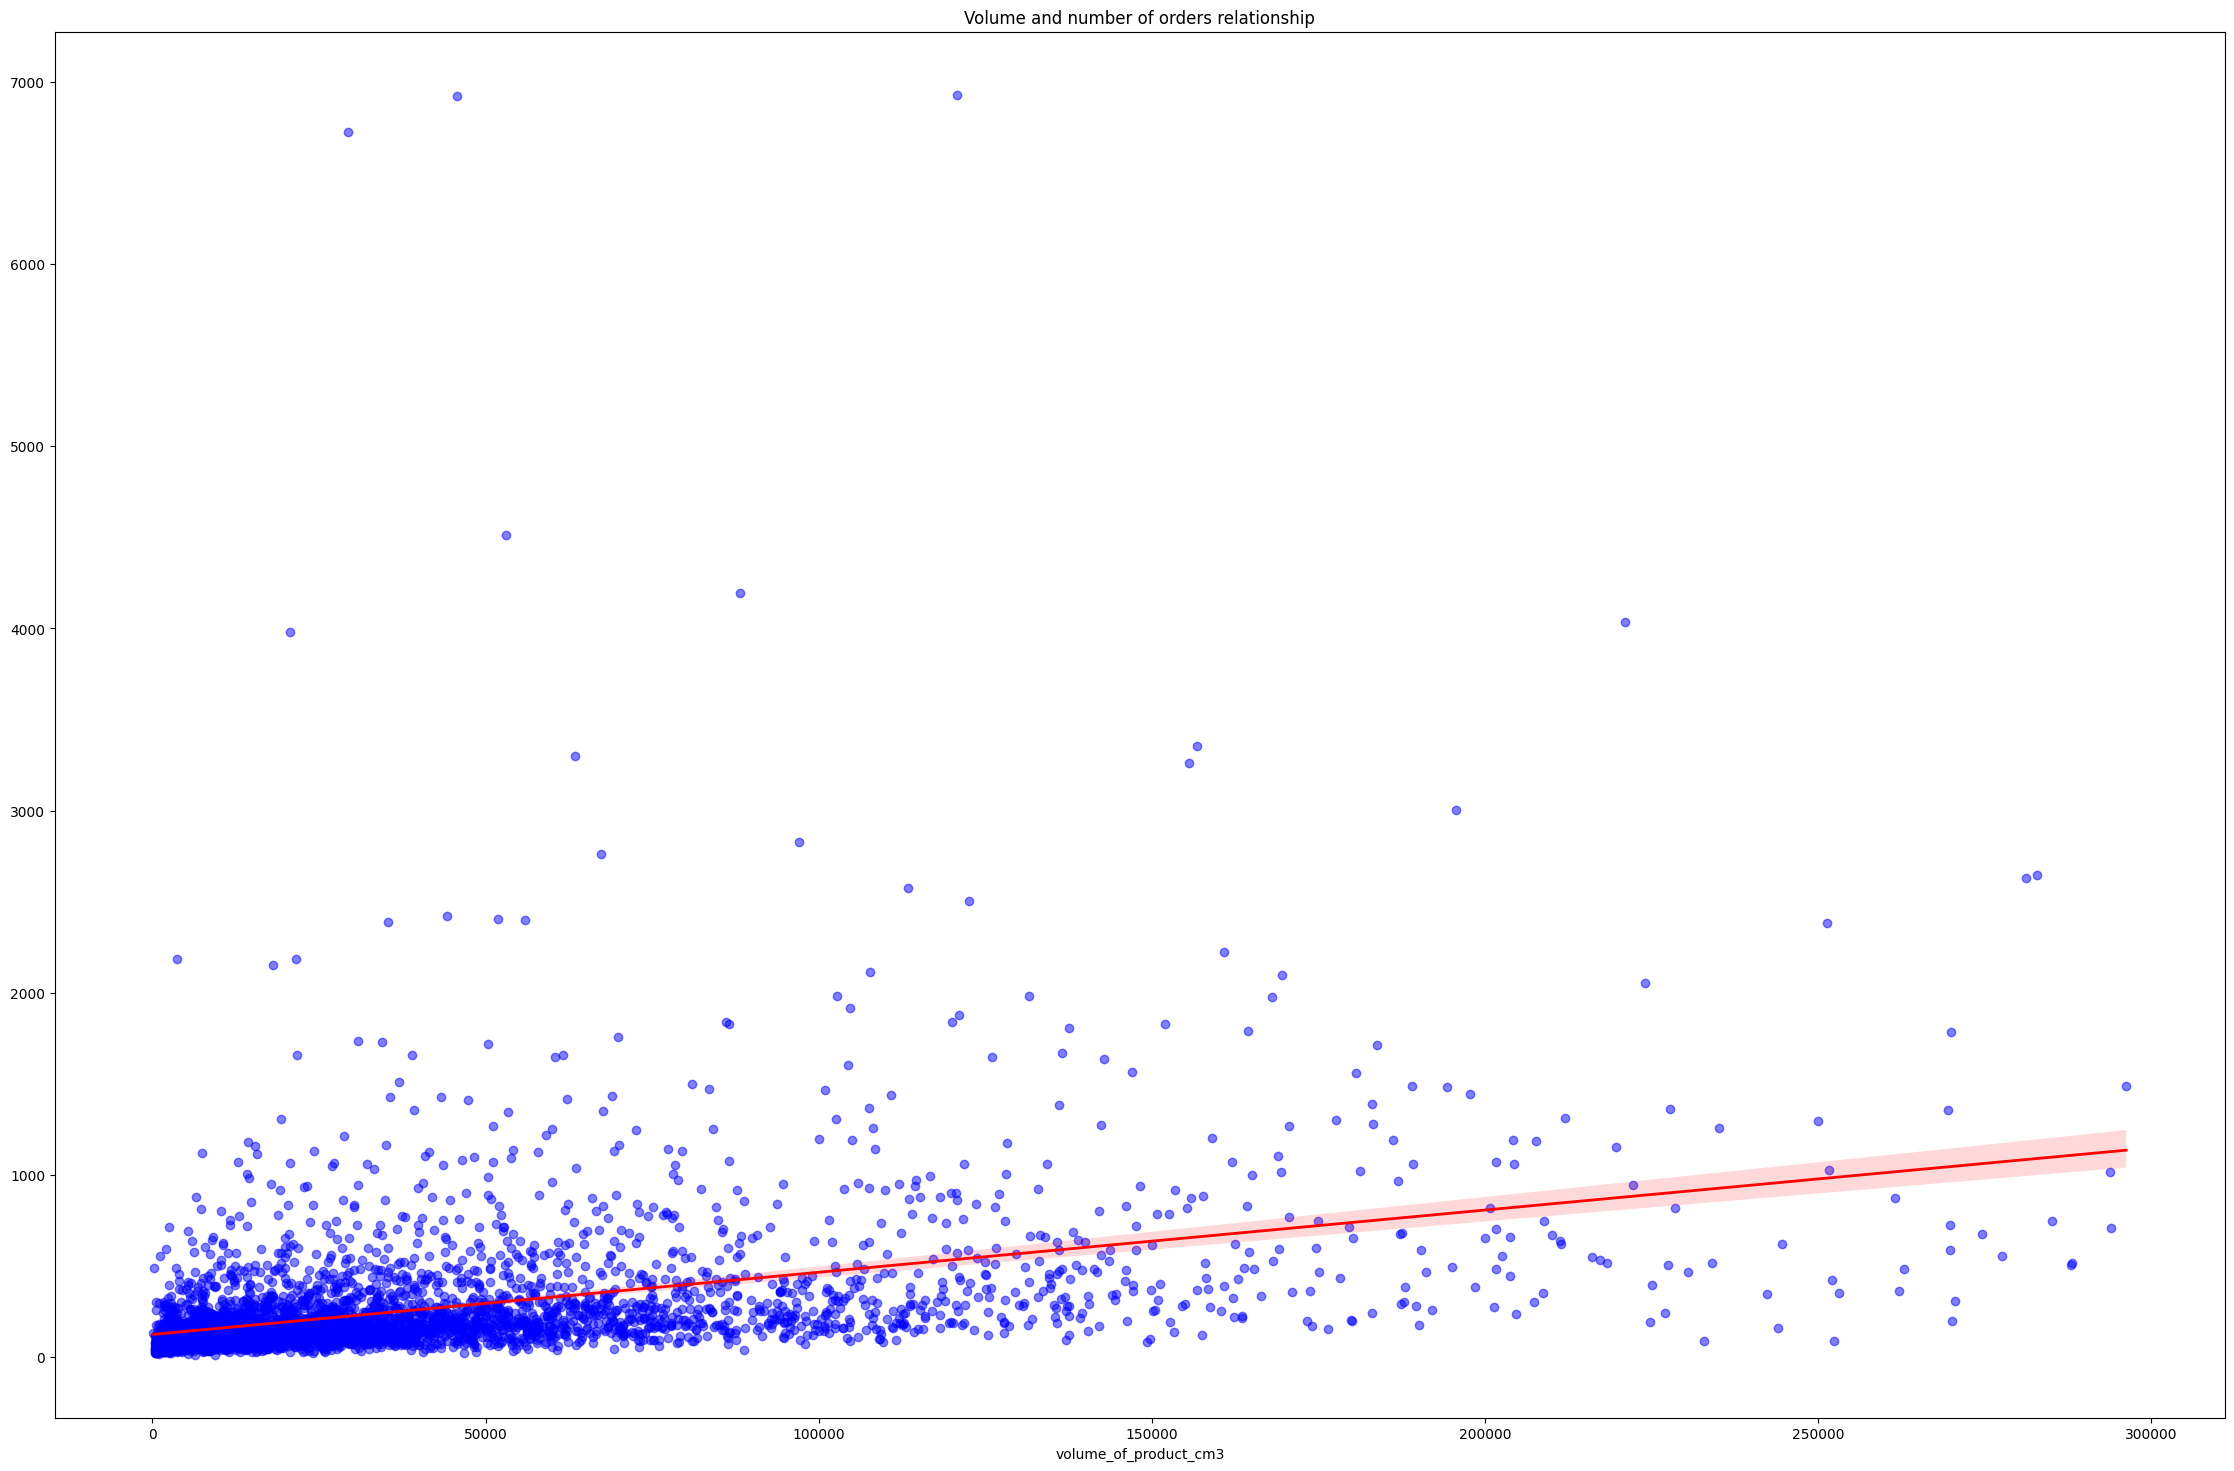

In [87]:
product_avg_revenue_volume=df_items_products_english.groupby("volume_of_product_cm3")["sum_original_and_freight_value"].mean() 
plt.figure(figsize=(28,18)) 
sns.regplot(x=product_avg_revenue_volume.index,y=product_avg_revenue_volume.values,scatter_kws={"color": "blue", "alpha": 0.5},line_kws={"color": "red", "linewidth": 2})
plt.title("Volume and number of orders relationship") 
plt.show()

In [88]:
#Insight:
#From the graph we can slightly see an increase in number of orders with volume

Text(0.5, 1.0, 'Relation between volume of product and freight value')

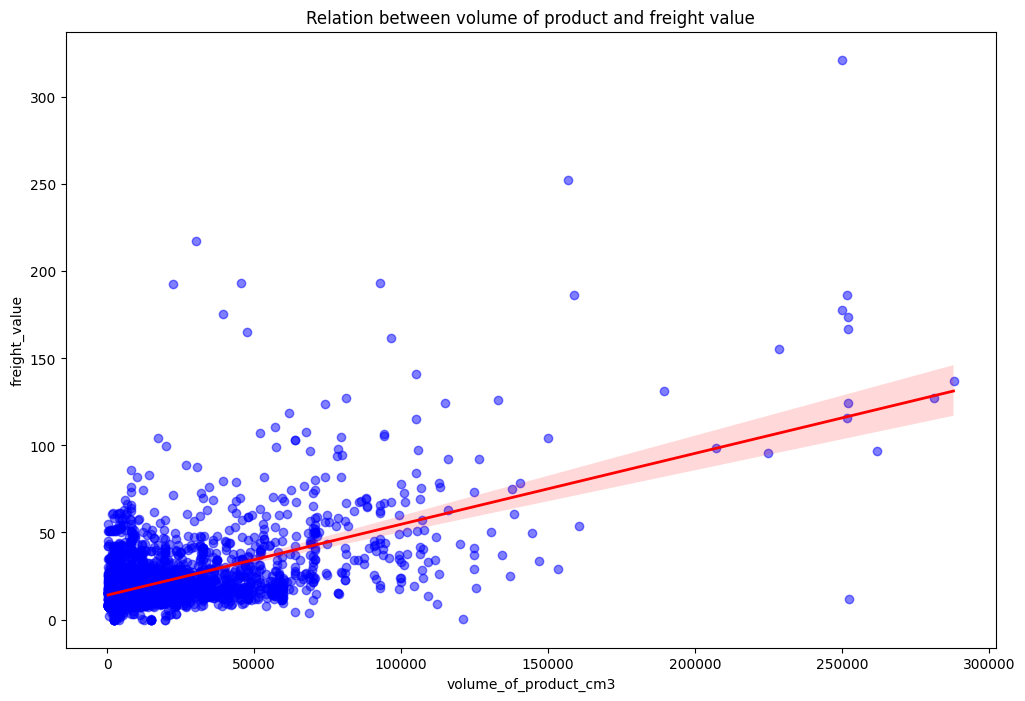

In [89]:
plt.figure(figsize=(12,8)) 
sns.regplot(data=df_items_products_english.sample(5000),x="volume_of_product_cm3",y="freight_value",scatter_kws={"color": "blue", "alpha": 0.5},line_kws={"color": "red", "linewidth": 2}) 
plt.title("Relation between volume of product and freight value")

In [90]:
#Insight:
#We can see the freight value slightly increases with the volume of products

### Section 4: Orders + Customers + Items + Products + Reviews

In [91]:
df_reviews=pd.read_csv("preprocessed_olist_order_reviews_dataset.csv")
df_reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,review_answer_time_taken
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59,0
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13,1
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24,1
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06,0
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53,1


In [92]:
df_reviews["review_creation_date"]=pd.to_datetime(df_reviews["review_creation_date"])
df_reviews["review_answer_timestamp"]=pd.to_datetime(df_reviews["review_answer_timestamp"])

In [93]:
df_order_items_reviews=df_base.merge(df_order_items,on="order_id",how="inner").merge(df_products,on="product_id",how="inner").merge(df_reviews,on="order_id",how="inner")
df_order_items_reviews.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'delivery_time', 'approval_time', 'carrier_time',
       'expected_vs_actual_delivery', 'customer_unique_id',
       'customer_zip_code_prefix', 'customer_city', 'customer_state',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'sum_original_and_freight_value',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'volume_of_product_cm3', 'review_id', 'review_score',
       'review_comment_title', 'review_comment_message',
       'review_creation_date', 'review_answer_timestamp',
       'review_answer_time_taken'],
      dtype='object')

In [94]:
df_order_items_reviews=pd.merge(df_order_items_reviews,df_translation,on="product_category_name",how="inner") 
df_order_items_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110727 entries, 0 to 110726
Data columns (total 40 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   order_id                        110727 non-null  object        
 1   customer_id                     110727 non-null  object        
 2   order_status                    110727 non-null  object        
 3   order_purchase_timestamp        110727 non-null  datetime64[ns]
 4   order_approved_at               110727 non-null  datetime64[ns]
 5   order_delivered_carrier_date    109584 non-null  datetime64[ns]
 6   order_delivered_customer_date   108442 non-null  datetime64[ns]
 7   order_estimated_delivery_date   110727 non-null  datetime64[ns]
 8   delivery_time                   108442 non-null  float64       
 9   approval_time                   110727 non-null  float64       
 10  carrier_time                    108442 non-null  float64

In [95]:
df_order_items_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110727 entries, 0 to 110726
Data columns (total 40 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   order_id                        110727 non-null  object        
 1   customer_id                     110727 non-null  object        
 2   order_status                    110727 non-null  object        
 3   order_purchase_timestamp        110727 non-null  datetime64[ns]
 4   order_approved_at               110727 non-null  datetime64[ns]
 5   order_delivered_carrier_date    109584 non-null  datetime64[ns]
 6   order_delivered_customer_date   108442 non-null  datetime64[ns]
 7   order_estimated_delivery_date   110727 non-null  datetime64[ns]
 8   delivery_time                   108442 non-null  float64       
 9   approval_time                   110727 non-null  float64       
 10  carrier_time                    108442 non-null  float64

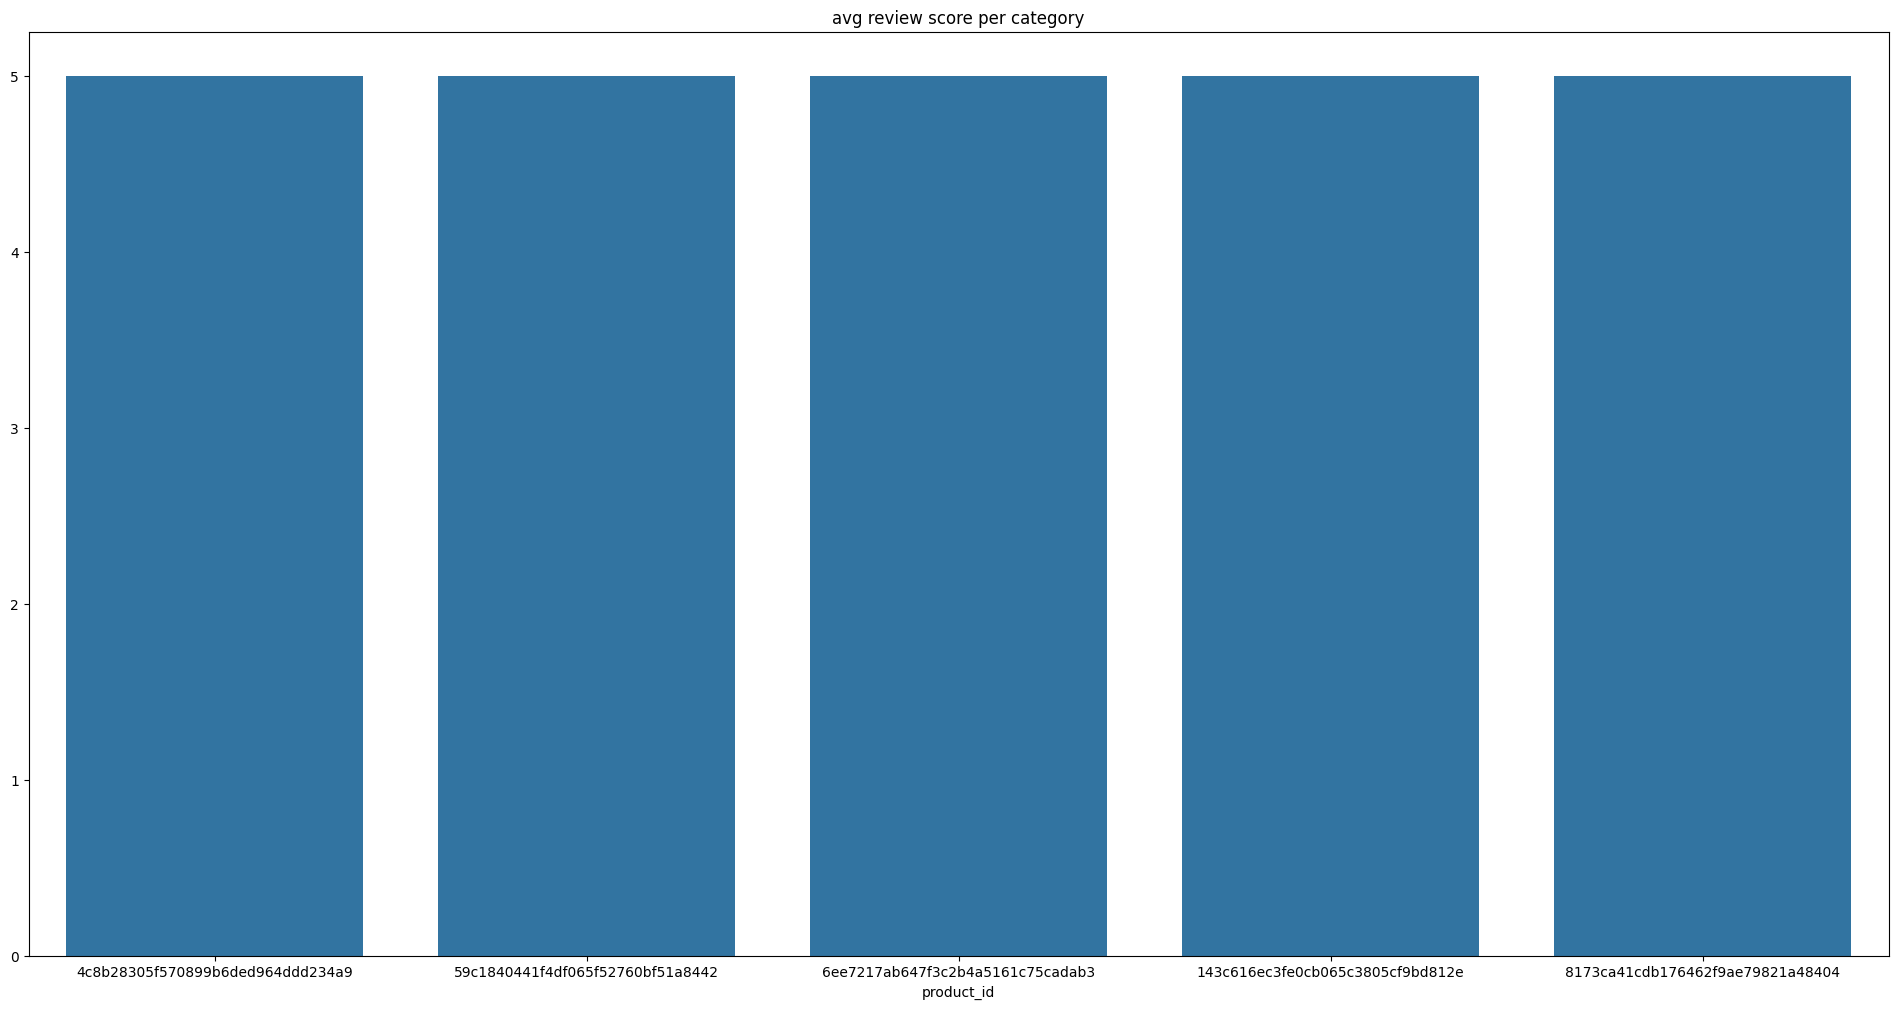

In [96]:
df_filtered=df_order_items_reviews.groupby("product_id").filter(lambda x:len(x)>10)
df_avg_prod_rev=df_filtered.groupby("product_id")["review_score"].mean().sort_values(ascending=False).head(5)

plt.figure(figsize=(24,12))
sns.barplot(x=df_avg_prod_rev.index,y=df_avg_prod_rev.values)
plt.title("avg review score per category")
plt.show()

In [97]:
#Insight:
#The top 5 products have 5 stars 

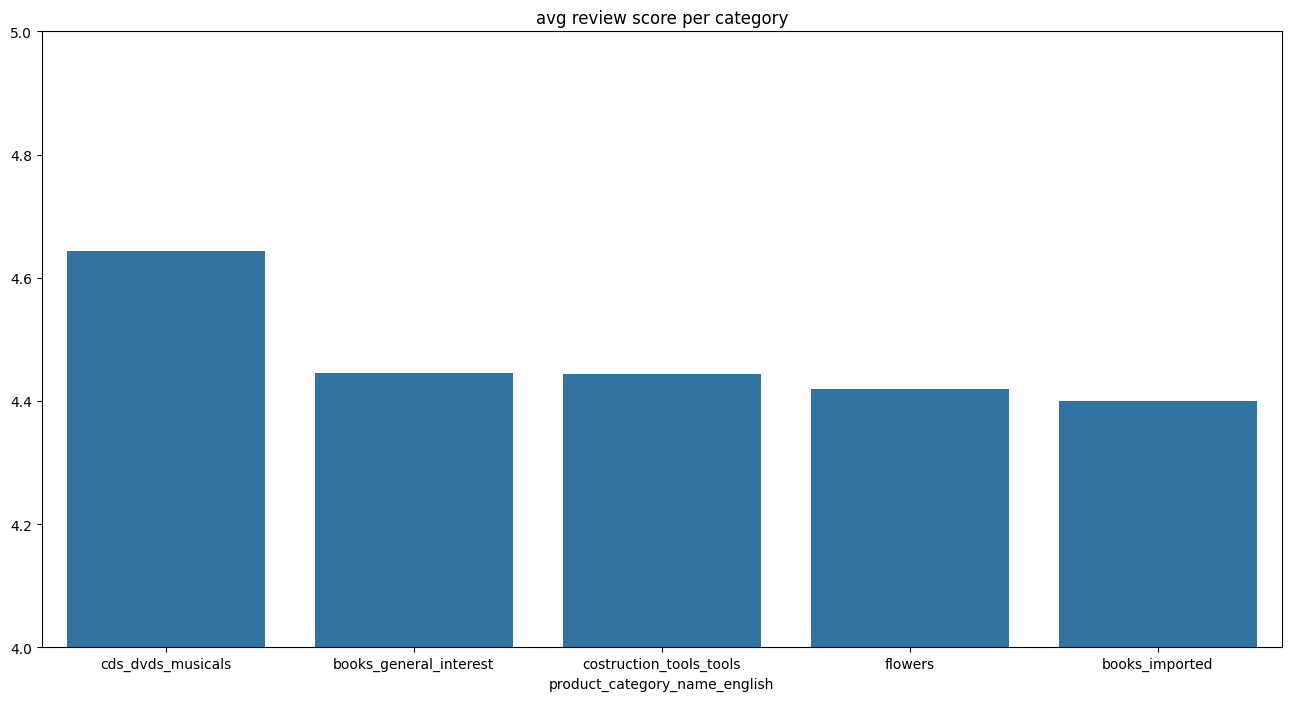

In [98]:
df_filtered_cat=df_order_items_reviews.groupby("product_category_name_english").filter(lambda x:len(x)>10)
df_avg_prod_cat_rev=df_filtered_cat.groupby("product_category_name_english")["review_score"].mean().sort_values(ascending=False).head(5)

plt.figure(figsize=(16,8))
sns.barplot(x=df_avg_prod_cat_rev.index,y=df_avg_prod_cat_rev.values)
plt.ylim(4,5)
plt.title("avg review score per category")
plt.show()

In [99]:
#Insight:
#Product categories like musicals, home applicances, tools are having high avg reviews

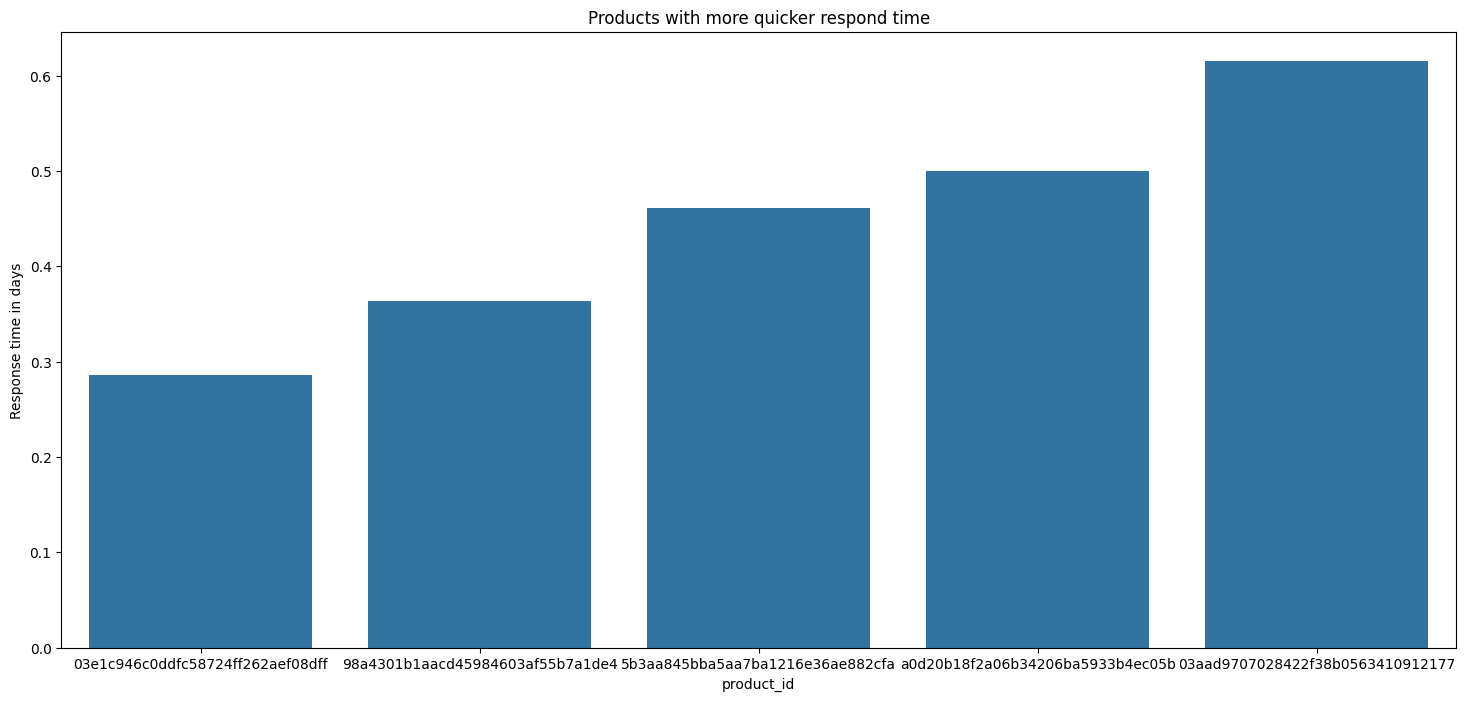

In [104]:
df_time_taken_review=df_filtered.groupby("product_id")["review_answer_time_taken"].mean().sort_values().head(5)

plt.figure(figsize=(18,8))
sns.barplot(x=df_time_taken_review.index,y=df_time_taken_review.values)
plt.title("Products with more quicker respond time")
plt.ylabel("Response time in days")
plt.show()

In [105]:
#Insight:
#The average time taken for top 5 products are within a day indicating the owners/marketing team is more active

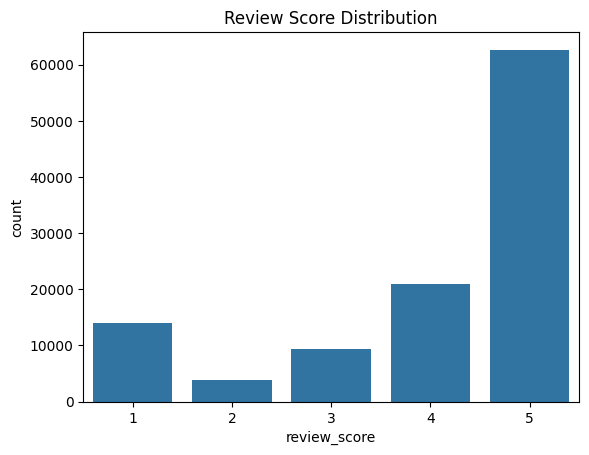

In [106]:
sns.countplot(x="review_score",data=df_order_items_reviews)
plt.title("Review Score Distribution")
plt.show()

In [107]:
#Insight:
#Overall the products were too good as the number of 5 starsand 4 stars were being high

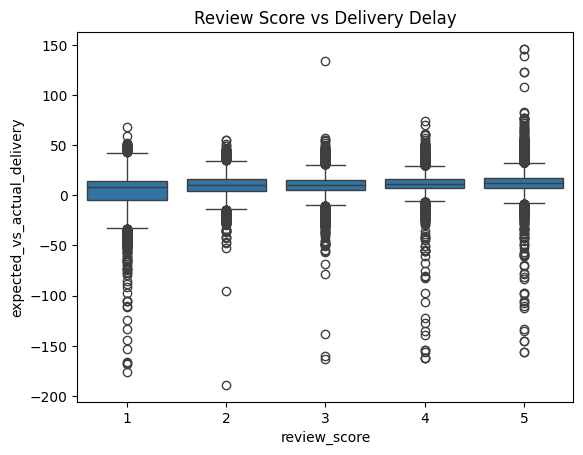

In [110]:
sns.boxplot(x="review_score",y="expected_vs_actual_delivery",data=df_order_items_reviews)
plt.title("Review Score vs Delivery Delay")
plt.show()

In [111]:
#Insight:
#SLightly we can see the delivery date beyond the expected leads to less review score

### Section 5: Orders + Customers + Items + Products + Reviews + Sellers

In [112]:
df_sellers=pd.read_csv("preprocessed_olist_sellers_dataset.csv")
df_sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [113]:
df_order_item_seller_analysis=df_base.merge(df_order_items,on="order_id",how="inner").merge(df_products,on="product_id",how="inner").merge(df_reviews,on="order_id",how="inner").merge(df_sellers,on="seller_id",how="inner")
df_order_item_seller_analysis.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'delivery_time', 'approval_time', 'carrier_time',
       'expected_vs_actual_delivery', 'customer_unique_id',
       'customer_zip_code_prefix', 'customer_city', 'customer_state',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'sum_original_and_freight_value',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'volume_of_product_cm3', 'review_id', 'review_score',
       'review_comment_title', 'review_comment_message',
       'review_creation_date', 'review_answer_timestamp',
       'review_answer_time_taken', 'seller_zip_code_prefix', 'seller_city',
      

In [114]:
df_order_item_seller_analysis=pd.merge(df_order_item_seller_analysis,df_translation,on="product_category_name",how="inner") 

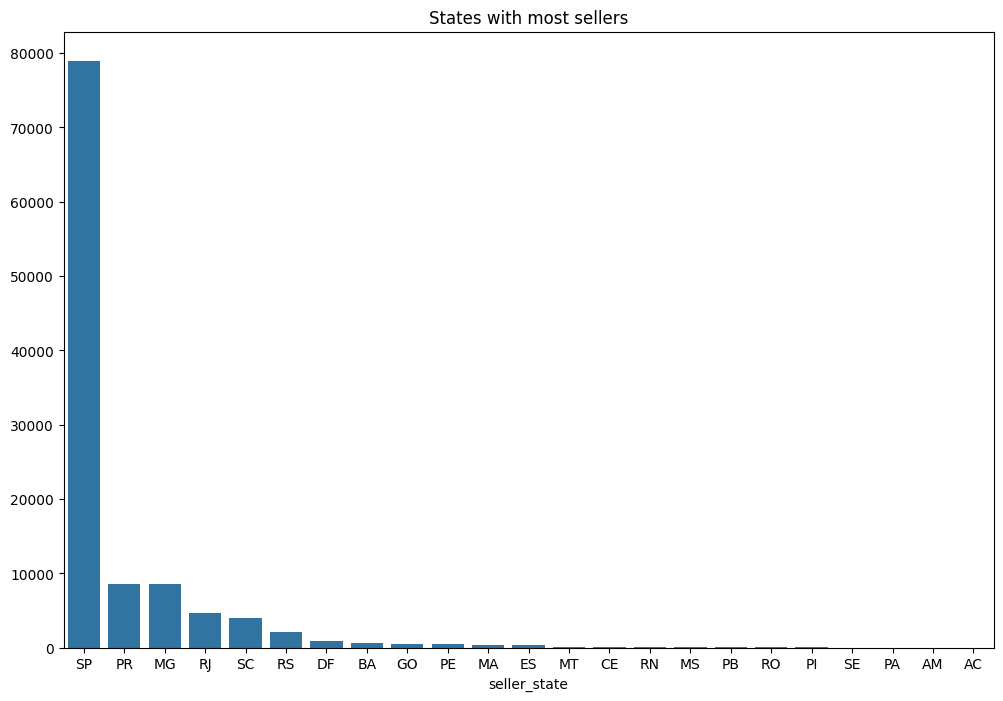

In [115]:
df_seller_state=df_order_item_seller_analysis["seller_state"].value_counts()

plt.figure(figsize=(12,8))
sns.barplot(x=df_seller_state.index,y=df_seller_state.values)
plt.title("States with most sellers")
plt.show()

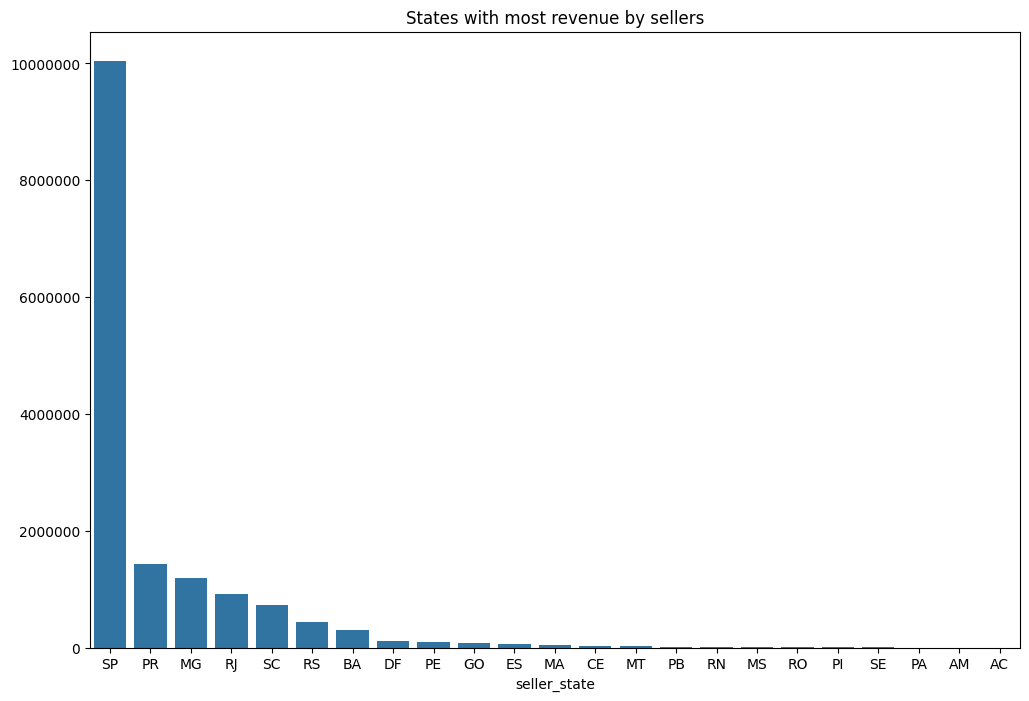

In [116]:
seller_city_revenue=df_order_item_seller_analysis.groupby("seller_state")["sum_original_and_freight_value"].sum().sort_values(ascending=False)

plt.figure(figsize=(12,8))
sns.barplot(x=seller_city_revenue.index,y=seller_city_revenue.values)
plt.ticklabel_format(axis='y',style='plain')
plt.title("States with most revenue by sellers")
plt.show()

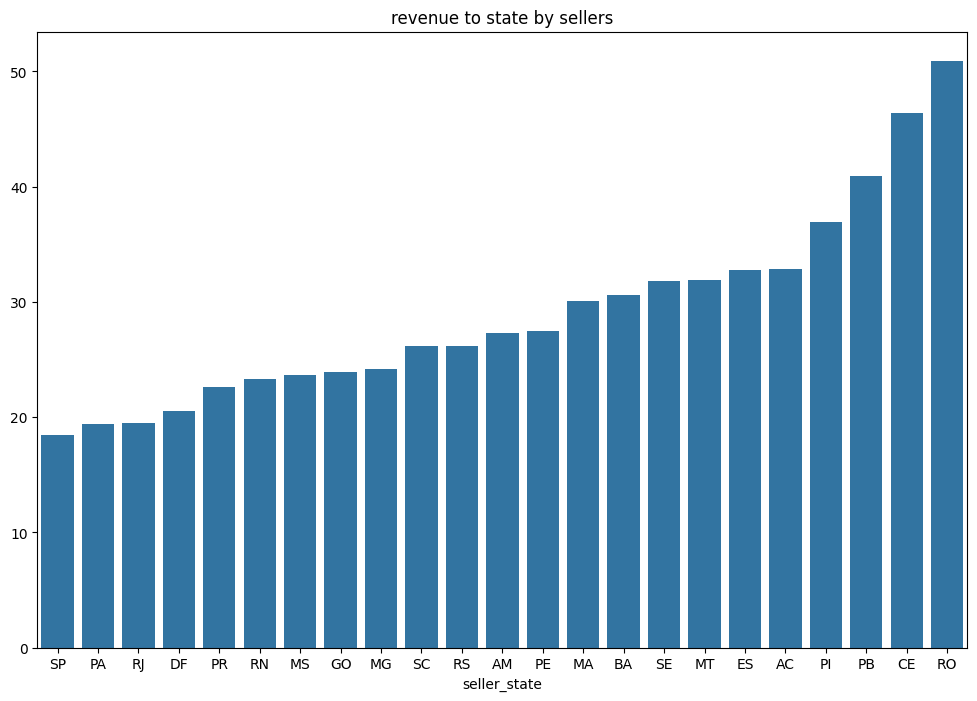

In [ ]:
seller_order_freight_revenue=df_order_item_seller_analysis.groupby("seller_state")["freight_value"].mean().sort_values()

plt.figure(figsize=(12,8))
sns.barplot(x=seller_order_freight_revenue.index,y=seller_order_freight_revenue.values)
plt.title("Avg revenue to state by sellers")
plt.show()

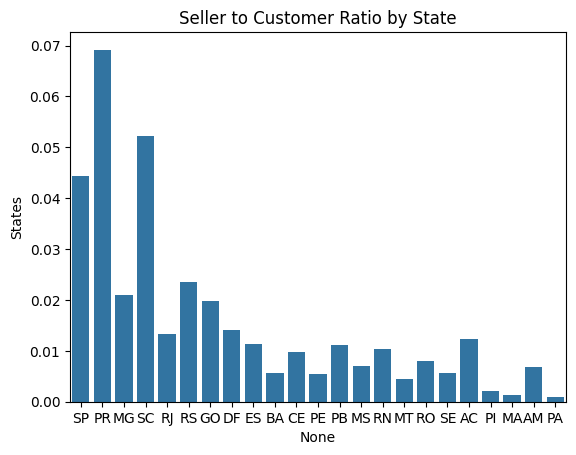

In [118]:
seller_count=df_sellers["seller_state"].value_counts()
customer_count=df_customers["customer_state"].value_counts()

df_compare=pd.merge(
    seller_count.rename("sellers"),
    customer_count.rename("customers"),
    left_index=True,
    right_index=True
)

df_compare["seller_to_customer_ratio"]=df_compare["sellers"]/df_compare["customers"]

sns.barplot(x=df_compare.index,y=df_compare["seller_to_customer_ratio"])
plt.title("Seller to Customer Ratio by State")
plt.ylabel("States")
plt.show()

In [119]:
#Insight:
#This indicates that most of the products that were sold belongs to the same state

Text(0.5, 1.0, 'Seller Rating Distribution')

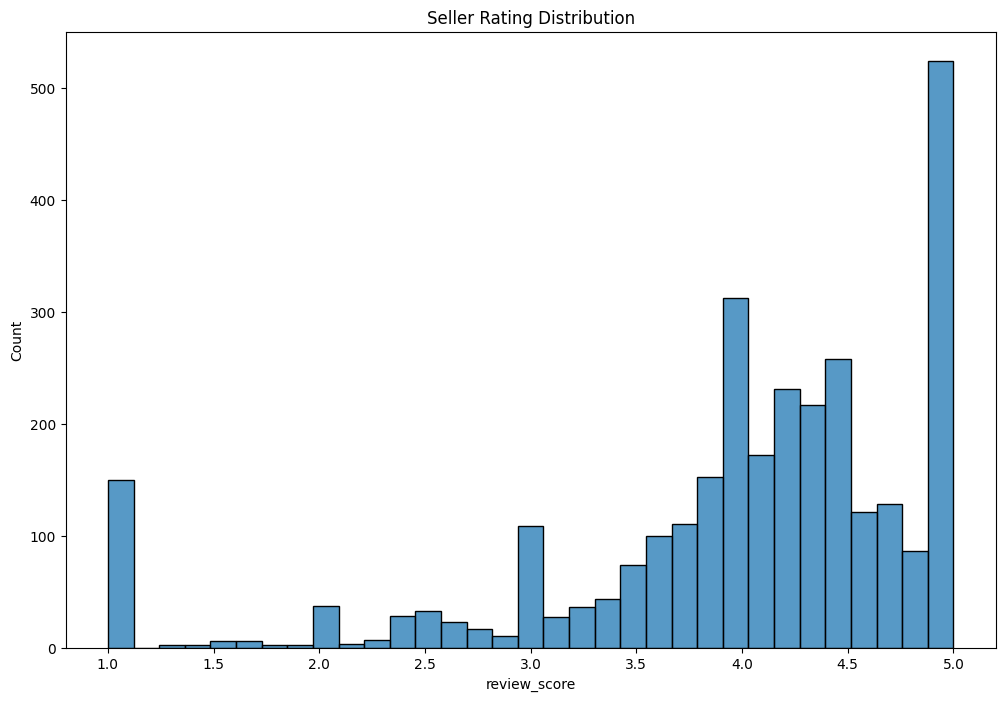

In [120]:
seller_avg_rating=df_order_item_seller_analysis.groupby("seller_id")["review_score"].mean()

plt.figure(figsize=(12,8))
sns.histplot(seller_avg_rating)
plt.title("Seller Rating Distribution")

In [121]:
#Insight:
#We could see most of the sellers has good ratings 

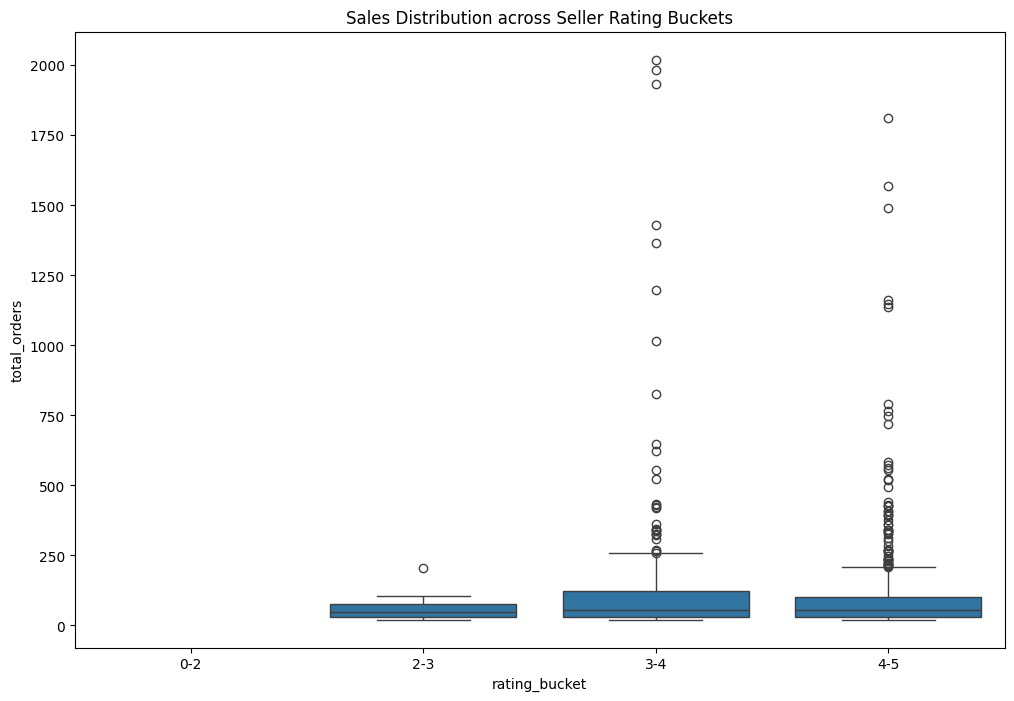

In [122]:
seller_perf=df_order_item_seller_analysis.groupby("seller_id").agg({
    "review_score": "mean",
    "order_id": "count"
}).reset_index()

seller_perf.columns=["seller_id","avg_rating","total_orders"]
seller_perf=seller_perf[seller_perf["total_orders"]>20]

seller_perf["rating_bucket"]=pd.cut(
    seller_perf["avg_rating"],
    bins=[0,2,3,4,5],
    labels=["0-2","2-3","3-4","4-5"]
)

plt.figure(figsize=(12,8))
sns.boxplot(data=seller_perf,x="rating_bucket",y="total_orders")
plt.title("Sales Distribution across Seller Rating Buckets")
plt.show()

In [123]:
#Insight:
#There is no clear positive relationship between seller rating and sales volume.In fact sellers with moderate ratings (3–4) show higher median order counts, indicating that scale of operations may impact ratings due to increased variability in customer experience

### Section 6: Orders + Customers + Items + Products + Reviews + Sellers + Payment

In [124]:
df_payment_initial=pd.read_csv("preprocessed_olist_order_payments_dataset.csv")
df_payment_initial.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [125]:
df_order_item_seller_analysis=df_base.merge(df_order_items,on="order_id",how="inner").merge(df_products,on="product_id",how="inner").merge(df_reviews,on="order_id",how="inner").merge(df_sellers,on="seller_id",how="inner").merge(df_payment_initial,on="order_id",how="inner")
df_order_item_seller_analysis.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'delivery_time', 'approval_time', 'carrier_time',
       'expected_vs_actual_delivery', 'customer_unique_id',
       'customer_zip_code_prefix', 'customer_city', 'customer_state',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'sum_original_and_freight_value',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'volume_of_product_cm3', 'review_id', 'review_score',
       'review_comment_title', 'review_comment_message',
       'review_creation_date', 'review_answer_timestamp',
       'review_answer_time_taken', 'seller_zip_code_prefix', 'seller_city',
      

In [126]:
df_payment=pd.merge(df_order_item_seller_analysis,df_translation,on="product_category_name",how="inner") 
df_payment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115586 entries, 0 to 115585
Data columns (total 47 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   order_id                        115586 non-null  object        
 1   customer_id                     115586 non-null  object        
 2   order_status                    115586 non-null  object        
 3   order_purchase_timestamp        115586 non-null  datetime64[ns]
 4   order_approved_at               115586 non-null  datetime64[ns]
 5   order_delivered_carrier_date    114393 non-null  datetime64[ns]
 6   order_delivered_customer_date   113194 non-null  datetime64[ns]
 7   order_estimated_delivery_date   115586 non-null  datetime64[ns]
 8   delivery_time                   113194 non-null  float64       
 9   approval_time                   115586 non-null  float64       
 10  carrier_time                    113194 non-null  float64

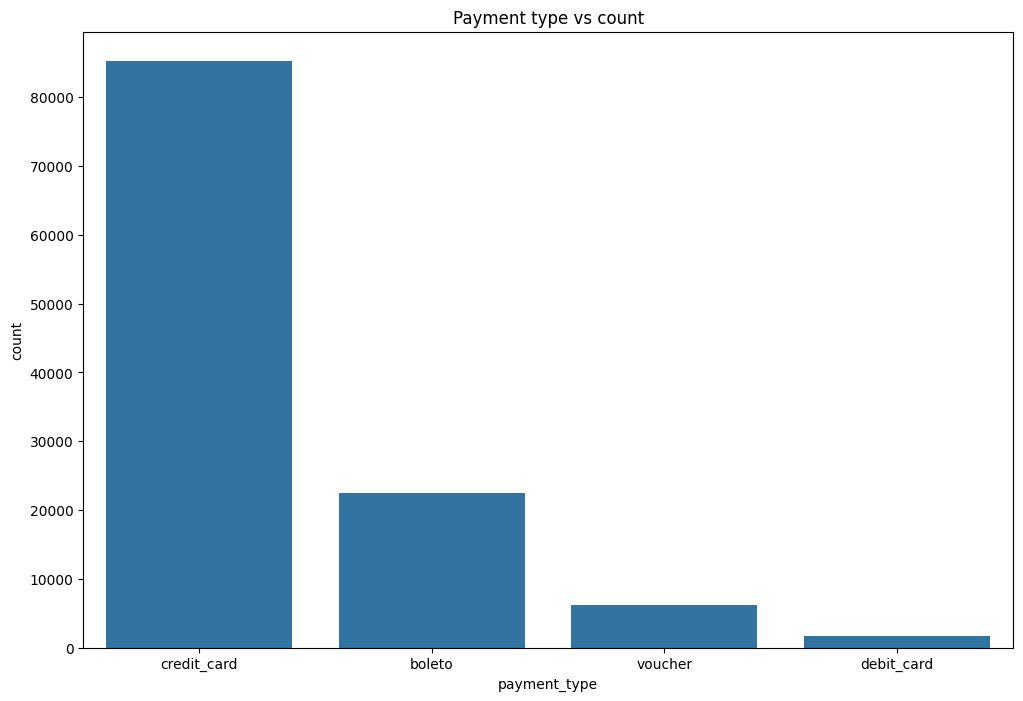

In [127]:
df_payment_type=df_payment["payment_type"].value_counts()

plt.figure(figsize=(12,8))
sns.barplot(df_payment_type)
plt.title("Payment type vs count")
plt.show()

In [128]:
#Insight:
#Credit cards dominate online transactions, indicating higher customer preference for flexible and installment-based payments"

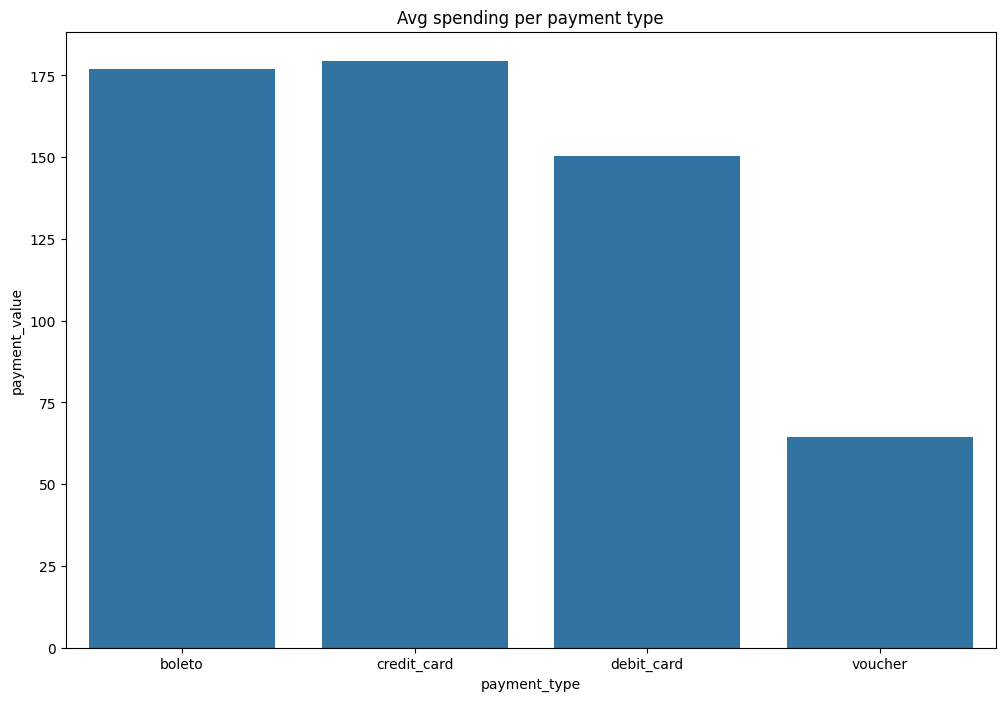

In [129]:
df_payment_type_spending=df_payment.groupby("payment_type")["payment_value"].mean()

plt.figure(figsize=(12,8))
sns.barplot(df_payment_type_spending)
plt.title("Avg spending per payment type")
plt.show()

In [130]:
#Insight:
#Credit,debit and boleto were almost similar and higher whereas voucher is being less 

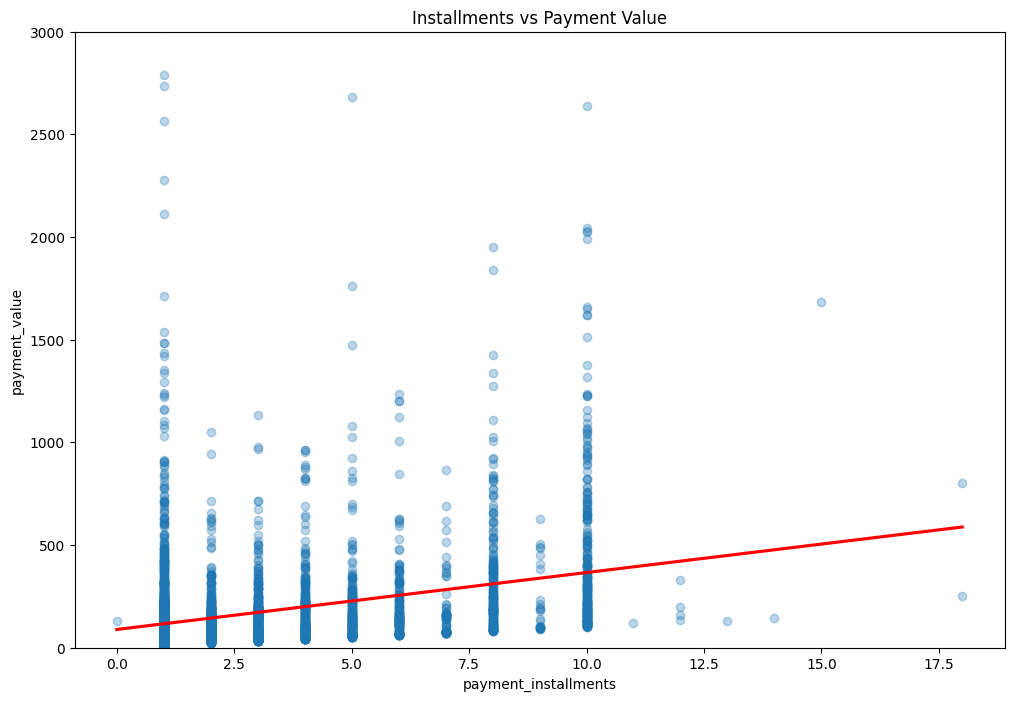

In [131]:
plt.figure(figsize=(12,8))

sns.regplot(
    data=df_payment.sample(5000),
    x="payment_installments",
    y="payment_value",
    scatter_kws={"alpha":0.3},
    line_kws={"color":"red"},
    ci=None
)

plt.ylim(0,3000)
plt.title("Installments vs Payment Value")
plt.show()

In [132]:
#Insight:
#Higher payment values tend to use more installments, especially for expensive purchases

Text(0.5, 1.0, 'Average Installments by Payment Type')

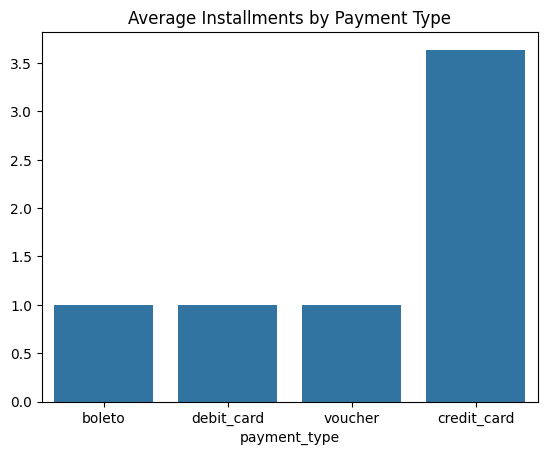

In [133]:
payment_installment=df_payment.groupby("payment_type")["payment_installments"].mean().sort_values()

sns.barplot(x=payment_installment.index, y=payment_installment.values)
plt.title("Average Installments by Payment Type")

In [134]:
#Insight:
#People using boleto, debit and voucher and all completing their payments in one time whereas credit card users using installments

Text(0.5, 1.0, 'Installment Usage Distribution')

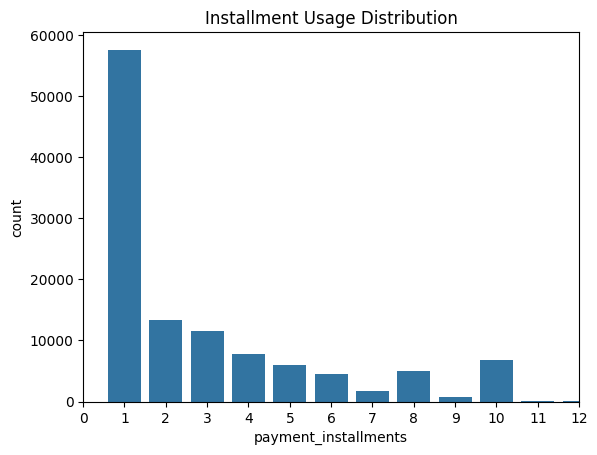

In [135]:
sns.countplot(x="payment_installments",data=df_payment)
plt.xlim(0,12)
plt.title("Installment Usage Distribution")

In [136]:
#Insight:
#People tend to complete their payment in one time rather than multiple installmentsa